### Main figures

Everything reads from the MAR outputs (1980–2100, SSP5-8.5) forced by
CNRM-CM6-1, IPSL-CM6A-LR, MPI-ESM1-2-HR and UKESM1-0-LL, run twice: `DS` with
the drifting-snow scheme on, `nDS` with it off. (=or wind-driven snow, WDS/nWDS) Also needed IMBIE-2 basin shapefile.  

`MAR_DATA_DIR` and `IMBIE_SHP` before running the codes.

Two warming thresholds (T_cross and T_moa) are used throughout, both expressed as warming above
1981–2010 over grounded ice in the 350–700 m elevation band:

- `T_MOA` — liquid water production (ME + RF) reaches 70% of net accumulation
  (SF − ER − SU)
- `T_CROSS` — runoff overtakes snow transport (wind-driven snow) as the dominant ablation process

Relative ablation is normalised by the precipitation of the nDS run:

```
rel_ER = 100 * [P_nDS - (SF_DS + RF_DS - ER_DS)] / P_nDS
rel_RU = 100 * RU_DS / P_nDS
```

Base setup adapted from the code created by Charles Amory. (full script uploaded as multiproj.pynb)

Note: before we used 'drifting snow' and 'snow transport' which is now referred to as 'wind-driven snow'. In the paper we renamed DS and nDs to WDS and nWDS

## Setup

In [ ]:
import os
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
import pandas as pd
import seaborn as sns
import xarray as xr
from matplotlib.colors import LinearSegmentedColormap, Normalize, TwoSlopeNorm
from matplotlib.patches import Patch
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from scipy import stats
from scipy.optimize import curve_fit
from shapely.geometry import LineString

warnings.filterwarnings("ignore")
sns.set_style("white")


DATA_DIR = Path(os.environ.get("MAR_DATA_DIR", "/Users/dashakan/Desktop/scripts_AIS"))
SHP_PATH = Path(os.environ.get(
    "IMBIE_SHP",
    "/Users/dashakan/Downloads/ANT_Basins_IMBIE2_v1.6/ANT_Basins_IMBIE2_v1.6.shp")) # change the paths on your local machine here
FIG_DIR = Path(os.environ.get("FIG_DIR", "figures"))
TAB_DIR = Path(os.environ.get("TABLE_DIR", "tables"))
FIG_DIR.mkdir(exist_ok=True)
TAB_DIR.mkdir(exist_ok=True)

CST_FILE = DATA_DIR / "MARcst-AN35km-176x148.cdf2"


REF0, REF1 = "1981-01-01", "2010-01-01"
FUT0, FUT1 = "2071-01-01", "2100-01-01"
YEARS = pd.date_range("1980-01-01", "2100-01-01", freq="YS")

RESOLUTION = 35_000        # m, MAR grid spacing
BAND = (350, 700)          # grounded-ice elevation band, m
MOA_THRESHOLD = 0.7
RISK_THRESHOLD = 6.0       # basin at risk


MODELS = {"CNRM": "goldenrod", "IPSL": "forestgreen",
          "MPI": "firebrick", "UKM": "navy"}
LONG_NAME = {"CNRM": "MAR-CNRM", "IPSL": "MAR-IPSL",
             "MPI": "MAR-MPI", "UKM": "MAR-UKESM"}
FILE_KEY = {"CNRM": "CNRM", "IPSL": "IPL", "MPI": "MPI", "UKM": "UKM"}

BASINS = ["A-Ap", "Ap-B", "B-C", "C-Cp", "Cp-D", "D-Dp", "Dp-E", "E-Ep", "Ep-F",
          "F-G", "G-H", "H-Hp", "Hp-I", "I-Ipp", "Ipp-J", "J-Jpp", "Jpp-K", "K-A"]

In [8]:
cst = xr.open_dataset(CST_FILE, decode_times=False, engine="netcdf4")


ais = cst["AIS"].where(cst["AIS"] > 0)
grd = cst["GROUND"].where(cst["GROUND"] > 30)
shf = cst["ICE"].where((cst["ICE"] > 30) & (cst["GROUND"] < 50) & (cst["ROCK"] < 30))
grd_msk = ais * grd * cst["AREA"] / 100
shf_msk = shf * cst["AREA"] / 100

SH = cst["SH"].values.astype(float)
AREA_2D = cst["AREA"].values.astype(float)
ICE = cst["ICE"].values > 0
GROUND = cst["GROUND"].values > 0
SHELF = ICE & ~GROUND
ais_mask = cst["AIS"].values > 0
lsm = cst["AIS"].values < 1

grd_frac = np.where(ais_mask & (cst["GROUND"].values > 30),
                    cst["GROUND"].values / 100.0, 0.0)
band_mask = np.isfinite(SH) & (SH >= BAND[0]) & (SH < BAND[1])
topo_grd = np.where(GROUND, np.where(ICE, SH, np.nan), np.nan)

x2D, y2D = np.meshgrid(cst["X"], cst["Y"])
assert x2D.shape == SH.shape, "plotting grid does not match the MAR field shape"

# MAR ships X/Y in km; EPSG:3031 wants metres.
KM_TO_M = 1000.0 if np.nanmax(np.abs(x2D)) < 1e5 else 1.0
x2m, y2m = x2D * KM_TO_M, y2D * KM_TO_M


def preprocess(ds):
  
    for key in ("SECTOR", "SECTOR1_1"):
        try:
            ds = ds.sel({key: 1})
        except (KeyError, ValueError):
            pass
    try:
        ds["TT"] = ds["TT"].sel(ATMLAY=0.99973)
    except (KeyError, ValueError):
        pass
    try:
        ds = ds.rename_dims({"x": "X", "y": "Y"})
    except ValueError:
        pass
    return ds


def open_mar(run, model):
    path = DATA_DIR / f"year-MAR-{run}_{FILE_KEY[model]}-1980-2100.nc"
    ds = xr.open_mfdataset(str(path), decode_times=False,
                           preprocess=preprocess, engine="netcdf4")
    ds["TIME"] = YEARS
    return ds


DS = {m: open_mar("DS", m) for m in MODELS}
NDS = {m: open_mar("nDS", m) for m in MODELS}

In [ ]:
gdf = gpd.read_file(SHP_PATH)
region_col = next(c for c in ("Subregion", "SUBREGION", "Regions", "Region", "NAME", "Name")
                  if c in gdf.columns)
gdf = gdf.to_crs("EPSG:3031")[[region_col, "geometry"]].dropna()
gdf[region_col] = (gdf[region_col].astype(str).str.strip()
                   .str.replace("[\u2013\u2014]", "-", regex=True))

gdf = gdf.dissolve(by=region_col, as_index=False).rename(columns={region_col: "Subregion"})


def label_grid(scale):
    pts = gpd.GeoDataFrame(
        {"i": np.arange(x2D.size)},
        geometry=gpd.points_from_xy((x2D * scale).ravel(), (y2D * scale).ravel()),
        crs="EPSG:3031")
    hit = (gpd.sjoin(pts, gdf, how="left", predicate="within")
           .groupby("i", sort=False)["Subregion"].first())
    out = np.full(x2D.size, None, dtype=object)
    out[hit.index.to_numpy(dtype=int)] = hit.to_numpy(dtype=object)
    return out.reshape(x2D.shape)



trials = []
for scale in (KM_TO_M, 1.0, 0.001):
    arr = label_grid(scale)
    on_ground = pd.notna(arr) & (grd_frac > 0)
    n = int(pd.Series(arr[on_ground]).nunique()) if on_ground.any() else 0
    trials.append((n, scale, arr))
n_found, COORD_SCALE, subreg = max(trials, key=lambda t: t[0])

if n_found < 15:
    raise RuntimeError(
        f"basin assignment failed: {n_found} basins over grounded ice. "
        "Check x2D/y2D units, axis order and shapefile CRS.")

present = [b for b in BASINS if np.any(((subreg == b) & band_mask & (grd_frac > 0)))]


In [10]:
def flat(da):
    """Drop every dimension that is not TIME, Y or X."""
    extra = [d for d in da.dims if d not in ("TIME", "Y", "X")]
    if extra:
        da = da.isel({d: 0 for d in extra}, drop=True)
    return da.reset_coords(drop=True).transpose("TIME", "Y", "X")


def weights(basin, mask=None):
    """Ice-fraction and projection weights for one basin inside an elevation band."""
    m = (subreg == basin) & (band_mask if mask is None else mask) & (grd_frac > 0)
    return grd_frac * m.astype(float) * AREA_2D


def aw_mean(da, w):
    """Area-weighted spatial mean, one value per year."""
    V = np.asarray(flat(da).values, dtype=float)
    out = np.full(V.shape[0], np.nan)
    for t in range(V.shape[0]):
        ok = np.isfinite(V[t]) & np.isfinite(w) & (w > 0)
        if ok.any():
            out[t] = np.sum(V[t][ok] * w[ok]) / np.sum(w[ok])
    return out


def tt_anomaly(ds, ref=None):
    """TT relative to the 1981-2010 mean of `ref` (defaults to the run itself)."""
    tt = flat(ds["TT"])
    base = tt if ref is None else flat(ref["TT"])
    return tt - base.sel(TIME=slice(REF0, REF1)).mean("TIME")


def moa_num(ds):
    """Liquid water production, ME + RF."""
    return flat(ds["ME"] + ds["RF"])


def moa_den(ds, run="DS"):
    """Net accumulation: SF - ER - SU with drifting snow, SF - SU without."""
    return flat(ds["SF"] - ds["ER"] - ds["SU"]) if run == "DS" else flat(ds["SF"] - ds["SU"])


def moa_ratio(ds, run="DS"):
    num, den = moa_num(ds), moa_den(ds, run)
    return xr.where(den > 0, num / den, np.nan)


def _mono_exp(x, a, b):
    return a * np.exp(b * x)


def _power_law(x, a, b):
    return a * np.power(x, b)


def fit_wessem(x, num, den, threshold=MOA_THRESHOLD, n_fit=300, extend=6.0):
    """
    fits are adopted from van Wessem (2023)

    Exponential for ME + RF, power law for net accumulation.
    """
    ok = np.isfinite(x) & np.isfinite(num) & np.isfinite(den)
    if ok.sum() < 10:
        return None
    x, num, den = x[ok], num[ok], den[ok]
    order = x.argsort()
    x, num, den = x[order], num[order], den[order]

    try:
        p_num, cov_num = curve_fit(_mono_exp, x, num,
                                   bounds=([0, 0], [1e6, 2]), maxfev=20000)
    except Exception:
        return None
    se_num = np.sqrt(np.diag(cov_num))

    pos = den > 0
    if pos.sum() < 10:
        return None
    shift = x[pos].min() - 0.1
    try:
        p_den, cov_den = curve_fit(_power_law, x[pos] - shift, den[pos],
                                   p0=[1, 0.5], bounds=([0, 0], [1e6, 10]), maxfev=20000)
    except Exception:
        return None
    se_den = np.sqrt(np.diag(cov_den))

    xs = np.linspace(x.min(), x.max() + extend, n_fit)
    ys_num = _mono_exp(xs, *p_num)
    ys_den = _power_law(xs - shift, *p_den)
    moa_line = threshold * ys_den

    try:
        hit = LineString(np.c_[xs, ys_num]).intersection(LineString(np.c_[xs, moa_line]))
        if hit.is_empty:
            t_moa = np.nan
        else:
            t_moa = list(hit.geoms)[0].x if hit.geom_type == "MultiPoint" else hit.x
        if np.isfinite(t_moa) and t_moa > xs.max():
            t_moa = np.nan
    except Exception:
        t_moa = np.nan

    return dict(x=xs, num_fit=ys_num, den_fit=ys_den, moa_line=moa_line,
                num_lo=_mono_exp(xs, p_num[0] - se_num[0], p_num[1]),
                num_hi=_mono_exp(xs, p_num[0] + se_num[0], p_num[1]),
                den_lo=_power_law(xs - shift, p_den[0] - se_den[0], p_den[1]),
                den_hi=_power_law(xs - shift, p_den[0] + se_den[0], p_den[1]),
                T_moa=t_moa)


FIELDS = {m: {"TT_ano": tt_anomaly(DS[m]), "NUM": moa_num(DS[m]), "DEN": moa_den(DS[m])}

          for m in MODELS}

### Figure 1a surface ablation as % of precipitation

Evolution of three ablation terms till 2100, each relative to the precipitation of
the nDS run, for grounded ice and ice shelves. Lines are the four-model mean,
shading is ±1.64 standard deviations. This plot is produced based on the code written by Charles Amory.

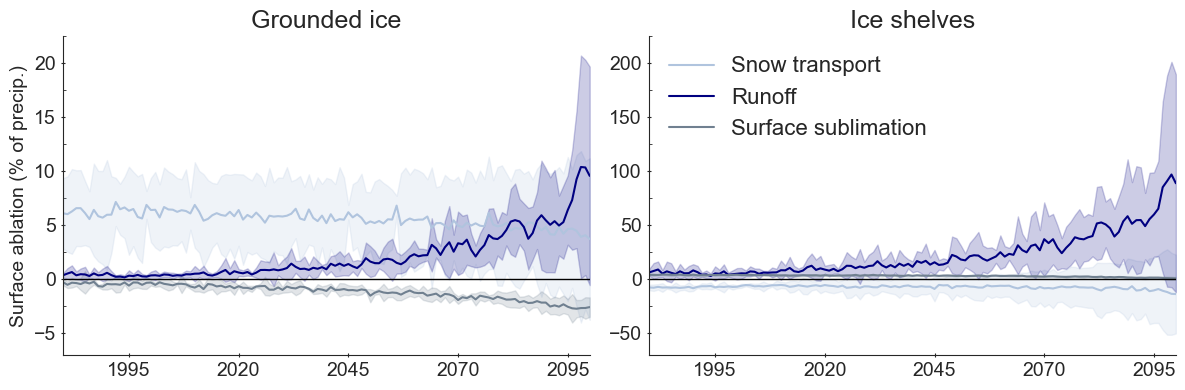

In [ ]:
COMPONENTS = {"Snow transport": "lightsteelblue",
              "Runoff": "navy",
              "Surface sublimation": "slategrey"}
REGIONS = {"Grounded ice": (grd_msk, (-7, 22.5)),
           "Ice shelves": (shf_msk, (-70, 225))}
SPREAD = 1.64


def integrate(ds, variables, mask):
    """Spatial integral over the masked area, Gt yr-1."""
    factor = RESOLUTION ** 2 / 1e12
    return {v: ((flat(ds[v]) * mask.values).sum(dim=["X", "Y"]) * factor).to_series()
            for v in variables}


def relative_ablation(ref, drift, mask):
    n = integrate(ref, ["SF", "RF"], mask)
    d = integrate(drift, ["SF", "RF", "ER", "RU", "SU"], mask)
    precip = n["SF"] + n["RF"]
    return pd.DataFrame({
        "Snow transport": (precip - (d["SF"] + d["RF"] - d["ER"])) / precip * 100,
        "Runoff": d["RU"] / precip * 100,
        "Surface sublimation": d["SU"] / precip * 100,
    })


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (title, (mask, ylim)) in zip(axes, REGIONS.items()):
    tables = {m: relative_ablation(NDS[m], DS[m], mask) for m in MODELS}
    for component, color in COMPONENTS.items():
        df = pd.DataFrame({m: t[component] for m, t in tables.items()})
        mean, std = df.mean(axis=1), df.std(axis=1)
        mean.plot(ax=ax, color=color, label=component)
        ax.fill_between(YEARS, mean + SPREAD * std, mean - SPREAD * std,
                        color=color, alpha=0.2)

    ax.set_title(title, fontsize=18)
    ax.set_ylim(*ylim)
    ax.set_xlabel("")
    ax.axhline(color="black", lw=1)
    ax.tick_params(axis="both", labelsize=14)
    ax.yaxis.set_minor_locator(AutoMinorLocator(n=2))
    ax.tick_params(axis="y", which="major", direction="inout", left=True, right=False)
    ax.tick_params(axis="y", which="minor", direction="in", left=True, right=False)
    ax.tick_params(axis="x", which="major", direction="inout", top=False, bottom=True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel("Surface ablation (% of precip.)", fontsize=14)
axes[1].set_ylabel("")
axes[1].legend(frameon=False, prop={"size": 16}, loc="upper left")

fig.tight_layout()
#fig.savefig(FIG_DIR / "fig1_surface_ablation.png", dpi=200, bbox_inches="tight")
plt.show()

### Figure 1b climate quadrant

Reference-period (1981-2010) near-surface temperature ('TT') against net deposition
(SF - ER) per basin, over grounded ice. Quadrants are split at the
medians. 

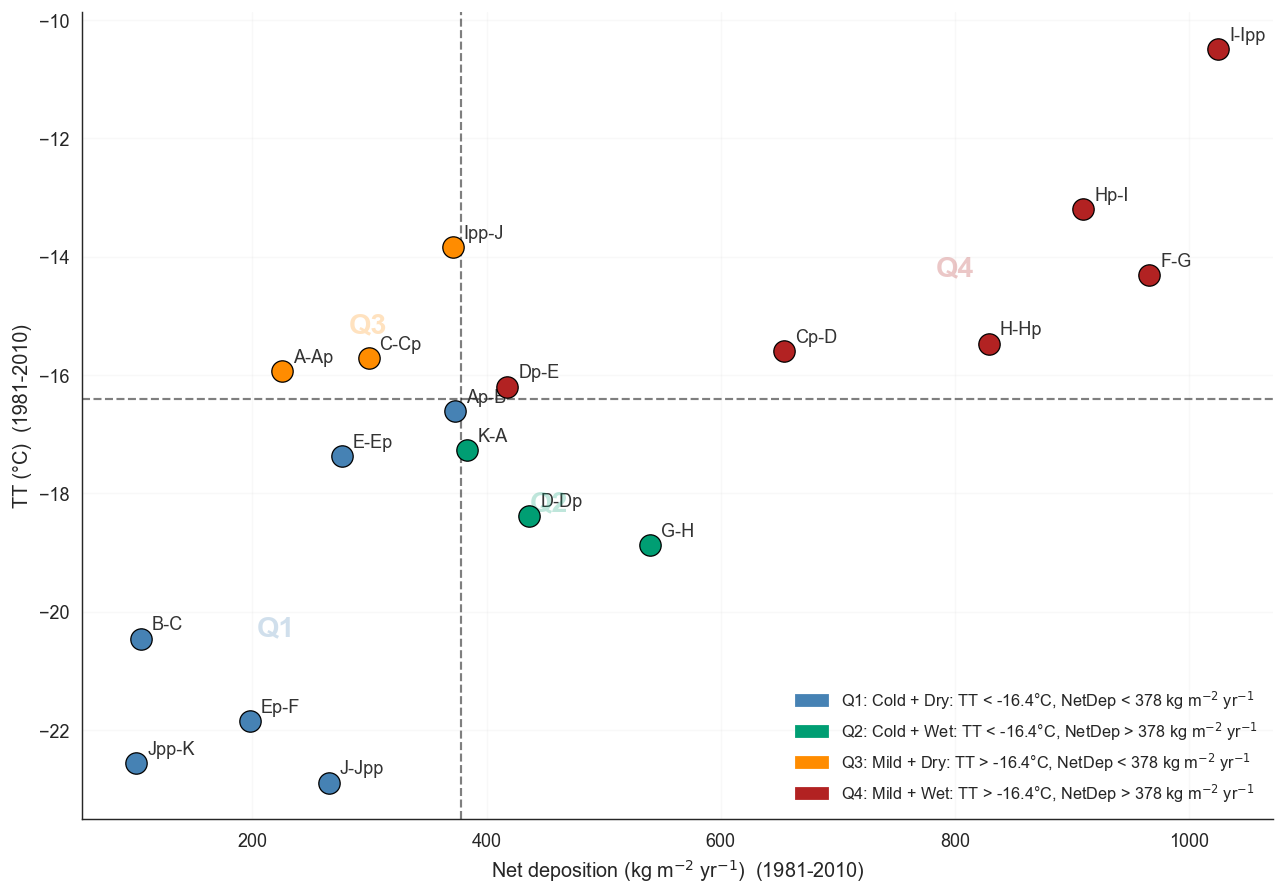

In [12]:
CLIM_BAND = (0, 1000)
UNIT = r"kg m$^{-2}$ yr$^{-1}$"

clim_mask = np.isfinite(SH) & (SH >= CLIM_BAND[0]) & (SH < CLIM_BAND[1])

rows = []
for basin in present:
    w = weights(basin, clim_mask)
    if not np.any(w > 0):
        continue
    for m in MODELS:
        ref = slice(REF0, REF1)
        rows.append({
            "basin": basin,
            "TT": np.nanmean(aw_mean(flat(DS[m]["TT"]).sel(TIME=ref), w)),
            "netdep": np.nanmean(aw_mean(flat(DS[m]["SF"] - DS[m]["ER"]).sel(TIME=ref), w)),
        })

climate = pd.DataFrame(rows).groupby("basin")[["TT", "netdep"]].mean()
med_TT = climate["TT"].median()
med_ND = climate["netdep"].median()

QUADRANTS = {
    "Q1": {"label": f"Cold + Dry: TT < {med_TT:.1f}°C, NetDep < {med_ND:.0f} {UNIT}",
           "color": "steelblue", "basins": []},
    "Q2": {"label": f"Cold + Wet: TT < {med_TT:.1f}°C, NetDep > {med_ND:.0f} {UNIT}",
           "color": "#009E73", "basins": []},
    "Q3": {"label": f"Mild + Dry: TT > {med_TT:.1f}°C, NetDep < {med_ND:.0f} {UNIT}",
           "color": "darkorange", "basins": []},
    "Q4": {"label": f"Mild + Wet: TT > {med_TT:.1f}°C, NetDep > {med_ND:.0f} {UNIT}",
           "color": "firebrick", "basins": []},
}

quadrant = {}
for basin, row in climate.iterrows():
    cold, dry = row["TT"] < med_TT, row["netdep"] < med_ND
    q = "Q1" if (cold and dry) else "Q2" if cold else "Q3" if dry else "Q4"
    quadrant[basin] = q
    QUADRANTS[q]["basins"].append(basin)

fig, ax = plt.subplots(figsize=(10, 7), dpi=130)

for basin, row in climate.iterrows():
    color = QUADRANTS[quadrant[basin]]["color"]
    ax.scatter(row["netdep"], row["TT"], s=140, color=color,
               edgecolor="black", lw=0.7, zorder=4)
    ax.annotate(basin, xy=(row["netdep"], row["TT"]), xytext=(6, 5),
                textcoords="offset points", fontsize=10, color="0.2")

ax.axvline(med_ND, color="black", lw=1.2, ls="--", alpha=0.5)
ax.axhline(med_TT, color="black", lw=1.2, ls="--", alpha=0.5)

for key, q in QUADRANTS.items():
    if not q["basins"]:
        continue
    sub = climate.loc[q["basins"]]
    ax.text(sub["netdep"].mean(), sub["TT"].mean(), key, fontsize=16,
            color=q["color"], ha="center", va="center", alpha=0.25, fontweight="bold")

ax.legend(handles=[Patch(color=q["color"], label=f"{k}: {q['label']}")
                   for k, q in QUADRANTS.items() if q["basins"]],
          frameon=False, fontsize=9, loc="lower right")
ax.set_xlabel(f"Net deposition ({UNIT})  (1981-2010)", fontsize=11)
ax.set_ylabel("TT (°C)  (1981-2010)", fontsize=11)
ax.grid(alpha=0.12)
sns.despine(ax=ax)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_climate_quadrant.png", dpi=200, bbox_inches="tight")
plt.show()

### Figure snow transport (wind-driven snow) vs. runoff, Here's for B-C and I-Ipp (Extended Data)

Relative ablation against basin warming, one row per forcing model, grounded ice
in the 350-700 m band. Bands are the 95% and 99% confidence intervals on a
degree-2 fit.

MAR-CNRM   B-C     T_cross(fit) = +1.67 °C
MAR-CNRM   I-Ipp   T_cross(fit) = -1.46 °C
MAR-IPSL   B-C     T_cross(fit) = +2.02 °C
MAR-IPSL   I-Ipp   T_cross(fit) = +0.80 °C
MAR-MPI    B-C     T_cross(fit) = +1.37 °C
MAR-MPI    I-Ipp   T_cross(fit) = +2.37 °C
MAR-UKESM  B-C     T_cross(fit) = +2.21 °C
MAR-UKESM  I-Ipp   T_cross(fit) = -2.01 °C


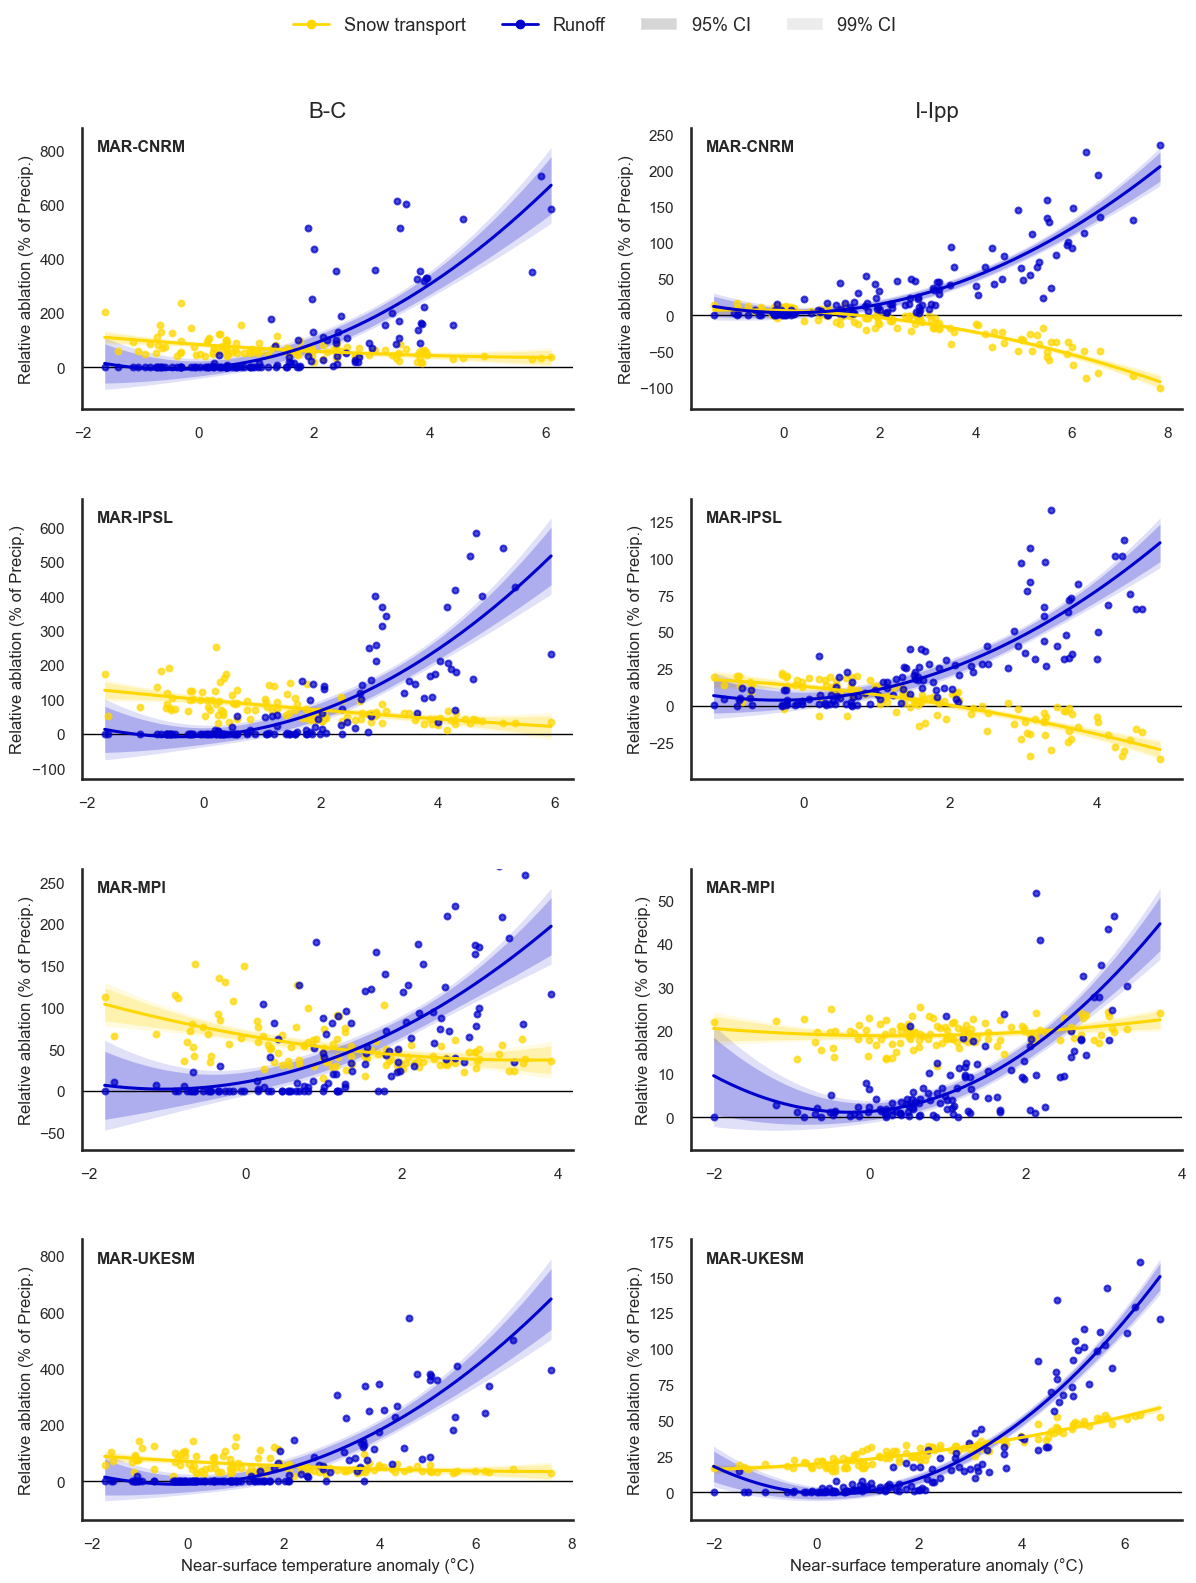

In [ ]:
PANEL_BASINS = ["B-C", "I-Ipp"]
DEG = 2
Y_QUANTILE = 92           # y-limits clip 
N_FIT = 200
COLORS = {"Snow transport": "gold", "Runoff": "mediumblue"}

sns.set_context("talk")   


def fit_ci(x, y, deg=DEG, n=N_FIT):
    """Polynomial fit with 95% and 99% confidence bands."""
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < deg + 3:
        return None
    xo, yo = x[ok], y[ok]
    X = np.vander(xo, deg + 1)
    beta = np.linalg.lstsq(X, yo, rcond=None)[0]
    dof = len(xo) - (deg + 1)
    resid_var = np.sum((yo - X @ beta) ** 2) / dof
    cov = resid_var * np.linalg.inv(X.T @ X)
    xs = np.linspace(np.nanmin(xo), np.nanmax(xo), n)
    Xs = np.vander(xs, deg + 1)
    ys = Xs @ beta
    se = np.sqrt(np.sum((Xs @ cov) * Xs, axis=1))
    return (xs, ys,
            ys - stats.t.ppf(0.975, dof) * se, ys + stats.t.ppf(0.975, dof) * se,
            ys - stats.t.ppf(0.995, dof) * se, ys + stats.t.ppf(0.995, dof) * se)


def curve_crossing(fit_er, fit_ru):
    
    if fit_er is None or fit_ru is None:
        return np.nan
    xs, diff = fit_er[0], fit_ru[1] - fit_er[1]
    if diff[0] > 0:
        return xs[0]
    idx = np.where((diff[:-1] <= 0) & (diff[1:] > 0))[0]
    if len(idx) == 0:
        return np.nan
    i = idx[0]
    return xs[i] + (xs[i + 1] - xs[i]) * (-diff[i]) / (diff[i + 1] - diff[i])


fig, axs = plt.subplots(len(MODELS), len(PANEL_BASINS), figsize=(12.5, 16))

for r, m in enumerate(MODELS):
    tta = tt_anomaly(DS[m])
    precip = flat(NDS[m]["SF"]) + flat(NDS[m]["RF"])
    netdep = flat(DS[m]["SF"]) + flat(DS[m]["RF"]) - flat(DS[m]["ER"])
    rel = {"Snow transport": 100.0 * (precip - netdep) / precip,
           "Runoff": 100.0 * flat(DS[m]["RU"]) / precip}

    for c, basin in enumerate(PANEL_BASINS):
        ax = axs[r, c]
        w = weights(basin)
        x = aw_mean(tta, w)
        y = {k: aw_mean(v, w) for k, v in rel.items()}

        fits = {}
        for name, color in COLORS.items():
            ax.scatter(x, y[name], s=18, color=color, alpha=0.7, zorder=3)
            fits[name] = fit_ci(x, y[name])
            if fits[name] is None:
                continue
            xs, ys, lo95, hi95, lo99, hi99 = fits[name]
            ax.fill_between(xs, lo99, hi99, color=color, alpha=0.12, lw=0, zorder=2)
            ax.fill_between(xs, lo95, hi95, color=color, alpha=0.22, lw=0, zorder=2)
            ax.plot(xs, ys, color=color, lw=2.2, zorder=4)

        pool = np.concatenate([v[np.isfinite(v)] for v in y.values()])
        band_lo = min(np.nanpercentile(pool, 100 - Y_QUANTILE),
                      min(np.nanmin(f[4]) for f in fits.values()), 0.0)
        band_hi = max(np.nanpercentile(pool, Y_QUANTILE),
                      max(np.nanmax(f[5]) for f in fits.values()))
        pad = 0.08 * (band_hi - band_lo)
        ax.set_ylim(band_lo - pad, band_hi + pad)

        tc = curve_crossing(fits["Snow transport"], fits["Runoff"])
        ax.axhline(0, color="black", lw=1)
        ax.text(0.03, 0.96, LONG_NAME[m], transform=ax.transAxes,
                fontsize=11.5, fontweight="bold", va="top")
        ax.xaxis.set_major_locator(MultipleLocator(2))
        ax.tick_params(axis="both", labelsize=11)
        ax.set_ylabel("Relative ablation (% of Precip.)", fontsize=12)
        if r == 0:
            ax.set_title(basin, fontsize=16, pad=8)
        if r == len(MODELS) - 1:
            ax.set_xlabel("Near-surface temperature anomaly (°C)", fontsize=12)

        print(f"{LONG_NAME[m]:10s} {basin:6s}  T_cross(fit) = "
              f"{'—' if not np.isfinite(tc) else format(tc, '+.2f')} °C")

fig.legend(handles=[plt.Line2D([0], [0], color=c, lw=2, marker="o", ms=6, label=k)
                    for k, c in COLORS.items()] +
                   [Patch(facecolor="0.55", alpha=0.35, label="95% CI"),
                    Patch(facecolor="0.55", alpha=0.16, label="99% CI")],
           loc="upper center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, 1.0), fontsize=13)
plt.subplots_adjust(left=0.09, right=0.97, top=0.92, bottom=0.05, wspace=0.24, hspace=0.32)
sns.despine()
fig.savefig(FIG_DIR / "fig3_transition_bands.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()
sns.set_context("notebook")

#### Table T_CROSS values

Warming at which runoff overtakes snow transport (wind-driven snow),
per basin and model, grounded ice 350-700 m. Crossing beyond the
simulated range (>2100) are `extrapolated` these values are marked in bold on the figure 2b.

In [ ]:
DEG = 2
T_EXTRAP_MAX = 12.0
OUT = TAB_DIR / "T_CROSS_table_350_700m_polyfit.csv"


def poly_cross(x, y_er, y_ru, deg=DEG, extrap_max=T_EXTRAP_MAX):
   
    ok_er = np.isfinite(x) & np.isfinite(y_er)
    ok_ru = np.isfinite(x) & np.isfinite(y_ru)
    if ok_er.sum() < deg + 5 or ok_ru.sum() < deg + 5:
        return np.nan, "no_cross"

    p_er = np.polyfit(x[ok_er], y_er[ok_er], deg)
    p_ru = np.polyfit(x[ok_ru], y_ru[ok_ru], deg)
    p_diff = p_ru - p_er                     

    x_min = max(np.nanmin(x[ok_er]), np.nanmin(x[ok_ru]))
    x_data_max = min(np.nanmax(x[ok_er]), np.nanmax(x[ok_ru]))
    x_max = max(x_data_max, extrap_max)

    roots = sorted(float(r.real) for r in np.roots(p_diff)
                   if abs(r.imag) < 1e-7 and x_min <= r.real <= x_max)
    for root in roots:
        if np.polyval(np.polyder(p_diff), root) > 0:
            return root, "data" if root <= x_data_max else "extrapolated"
    return np.nan, "no_cross"


rows = []
for m in MODELS:
    tta = tt_anomaly(DS[m])
    precip = flat(NDS[m]["SF"]) + flat(NDS[m]["RF"])
    netdep = flat(DS[m]["SF"]) + flat(DS[m]["RF"]) - flat(DS[m]["ER"])
    rel_er = xr.where(precip > 0, 100.0 * (precip - netdep) / precip, np.nan)
    rel_ru = xr.where(precip > 0, 100.0 * flat(DS[m]["RU"]) / precip, np.nan)

    for basin in BASINS:
        w = weights(basin)
        if not np.any(w > 0):
            rows.append({"basin": basin, "model": m, "T_CROSS": np.nan, "flag": "no_cells"})
            continue
        tcross, flag = poly_cross(aw_mean(tta, w), aw_mean(rel_er, w), aw_mean(rel_ru, w))
        rows.append({"basin": basin, "model": m, "T_CROSS": tcross, "flag": flag})
    print(f"{m}: done")

long_tcross = pd.DataFrame(rows)

df_tcross = long_tcross.pivot(index="basin", columns="model", values="T_CROSS")
df_tcross = df_tcross.reindex(index=BASINS, columns=list(MODELS))
df_tcross["Mean"] = df_tcross[list(MODELS)].mean(axis=1)
df_tcross["Min"] = df_tcross[list(MODELS)].min(axis=1)
df_tcross["Max"] = df_tcross[list(MODELS)].max(axis=1)
flags = long_tcross.pivot(index="basin", columns="model", values="flag").reindex(BASINS)
for m in MODELS:
    df_tcross[f"{m}_flag"] = flags[m]

df_tcross = df_tcross.reset_index().rename(columns={"basin": "Basin"})
df_tcross.to_csv(OUT, index=False, float_format="%.3f")
print(f"\nsaved {OUT}")
display(df_tcross[["Basin"] + list(MODELS) + ["Mean", "Min", "Max"]].round(2))

CNRM: done
IPSL: done
MPI: done
UKM: done

saved tables/T_CROSS_table_350_700m_polyfit.csv


model,Basin,CNRM,IPSL,MPI,UKM,Mean,Min,Max
0,A-Ap,4.06,4.26,3.22,5.14,4.17,3.22,5.14
1,Ap-B,2.58,2.35,1.53,3.64,2.52,1.53,3.64
2,B-C,1.67,2.02,1.37,2.21,1.82,1.37,2.21
3,C-Cp,2.97,3.27,2.32,4.51,3.27,2.32,4.51
4,Cp-D,2.45,2.51,2.40,4.55,2.98,2.40,4.55
5,D-Dp,4.19,3.72,4.99,6.20,4.77,3.72,6.20
6,Dp-E,0.98,0.18,0.04,1.01,0.55,0.04,1.01
7,E-Ep,4.34,3.44,4.56,4.39,4.18,3.44,4.56
8,Ep-F,2.04,3.54,NaN,NaN,2.79,2.04,3.54
9,F-G,3.92,5.40,4.66,NaN,4.66,3.92,5.40


#### Table T_MOA values

Warming at which liquid water production reaches 70% of net accumulation, adapted from van Wessem et al., 2023. `pooled` fits all four models together; `mean`/`std`/`range`
extrapolated values (>2100) are in bold on the figure 2a.

In [17]:
OUT = TAB_DIR / "TMOA_table_350_700m.csv"

records = []
for basin in present:
    w = weights(basin)
    pooled_x, pooled_num, pooled_den = [], [], []

    for m in MODELS:
        f = FIELDS[m]
        x = aw_mean(f["TT_ano"], w)
        num = aw_mean(f["NUM"], w)
        den = aw_mean(f["DEN"], w)
        ok = np.isfinite(x) & np.isfinite(num) & np.isfinite(den)
        if ok.sum() < 10:
            continue

        fit = fit_wessem(x[ok], num[ok], den[ok])
        records.append({"basin": basin, "model": m,
                        "T_MOA": fit["T_moa"] if fit else np.nan,
                        "x_max": float(np.nanmax(x))})
        pooled_x.extend(x[ok])
        pooled_num.extend(num[ok])
        pooled_den.extend(den[ok])

    pooled = fit_wessem(np.array(pooled_x), np.array(pooled_num),
                        np.array(pooled_den)) if len(pooled_x) >= 10 else None
    records.append({"basin": basin, "model": "pooled",
                    "T_MOA": pooled["T_moa"] if pooled else np.nan, "x_max": np.nan})

long_tmoa = pd.DataFrame(records)

df_tmoa = (long_tmoa.pivot_table(index="basin", columns="model", values="T_MOA",
                                 aggfunc="first")
           .reindex(index=present, columns=list(MODELS) + ["pooled"]))
per_model = list(MODELS)
df_tmoa["n_reach"] = df_tmoa[per_model].notna().sum(axis=1)
df_tmoa["mean"] = df_tmoa[per_model].mean(axis=1).round(2)
df_tmoa["std"] = df_tmoa[per_model].std(axis=1).round(2)
df_tmoa["min"] = df_tmoa[per_model].min(axis=1).round(2)
df_tmoa["max"] = df_tmoa[per_model].max(axis=1).round(2)
df_tmoa["range"] = (df_tmoa["max"] - df_tmoa["min"]).round(2)

df_tmoa = df_tmoa.rename_axis(None, axis=1).reset_index()
df_tmoa.to_csv(OUT, index=False, float_format="%.3f")
print(f"T_MOA (°C above 1981-2010) at MOA = {MOA_THRESHOLD}, "
      f"{BAND[0]}-{BAND[1]} m grounded ice")
print(f"basins where all {len(MODELS)} models reach the threshold: "
      f"{int((df_tmoa['n_reach'] == len(MODELS)).sum())} of {len(present)}")
print(f"saved {OUT}\n")
display(df_tmoa.round(2).set_index("basin"))

T_MOA (°C above 1981-2010) at MOA = 0.7, 350-700 m grounded ice
basins where all 4 models reach the threshold: 18 of 18
saved tables/TMOA_table_350_700m.csv



,CNRM,IPSL,MPI,UKM,pooled,n_reach,mean,std,min,max,range
basin,,,,,,,,,,,
A-Ap,4.16,4.54,4.09,5.40,4.73,4,4.55,0.60,4.09,5.40,1.31
Ap-B,3.87,3.62,3.55,5.54,4.52,4,4.14,0.94,3.55,5.54,1.99
B-C,1.59,2.10,2.47,2.33,1.98,4,2.12,0.39,1.59,2.47,0.88
C-Cp,2.87,3.41,2.88,5.03,3.83,4,3.55,1.02,2.87,5.03,2.16
Cp-D,4.35,4.34,4.57,5.92,5.13,4,4.80,0.75,4.34,5.92,1.58
D-Dp,4.36,3.43,4.77,5.70,4.74,4,4.56,0.94,3.43,5.70,2.27
Dp-E,4.50,3.54,3.42,5.12,4.45,4,4.15,0.81,3.42,5.12,1.70
E-Ep,4.37,3.31,5.12,4.05,4.05,4,4.21,0.75,3.31,5.12,1.81
Ep-F,6.95,7.87,7.13,8.16,7.49,4,7.53,0.58,6.95,8.16,1.21


### Figure 2 T_MOA and T_CROSS spatial maps

Per-pixel warming at which each threshold is first crossed, averaged over the
four models. Both maps share the colour scale: blue means the pixel has already
crossed in the reference climate, red is warming still needed. The purple
contours mark the 350 and 700 m band where the chnage in the ablation regime happens (wind-driven snow > to meltwater runoff). 


T_MOA  CNRM   crossed  2618 px   already exceeded   332 px   median +2.96
T_MOA  IPSL   crossed  2362 px   already exceeded   259 px   median +2.31
T_MOA  MPI    crossed  1428 px   already exceeded   336 px   median +1.33
T_MOA  UKM    crossed  2221 px   already exceeded   189 px   median +4.53
T_CROSS CNRM   crossed  2394 px   already exceeded   264 px   median +4.16
T_CROSS IPSL   crossed  2176 px   already exceeded   260 px   median +3.07
T_CROSS MPI    crossed  1477 px   already exceeded   215 px   median +1.27
T_CROSS UKM    crossed  2000 px   already exceeded   150 px   median +4.32


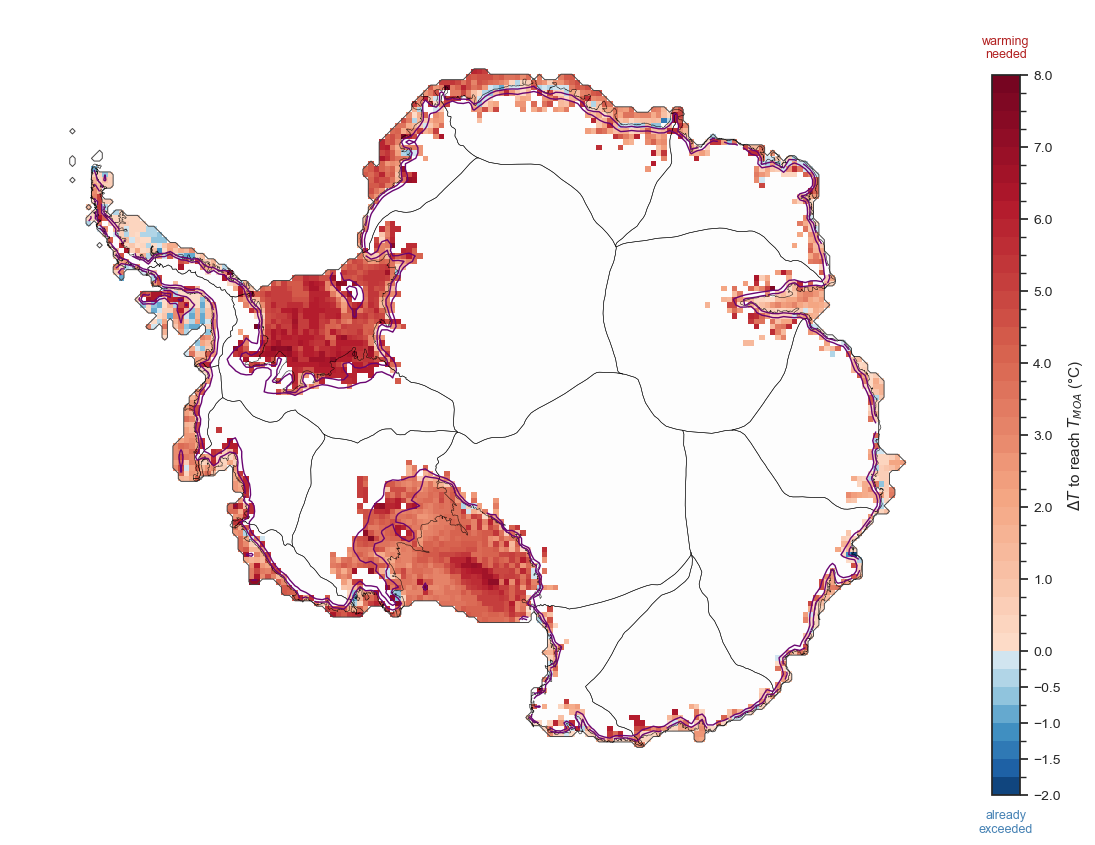

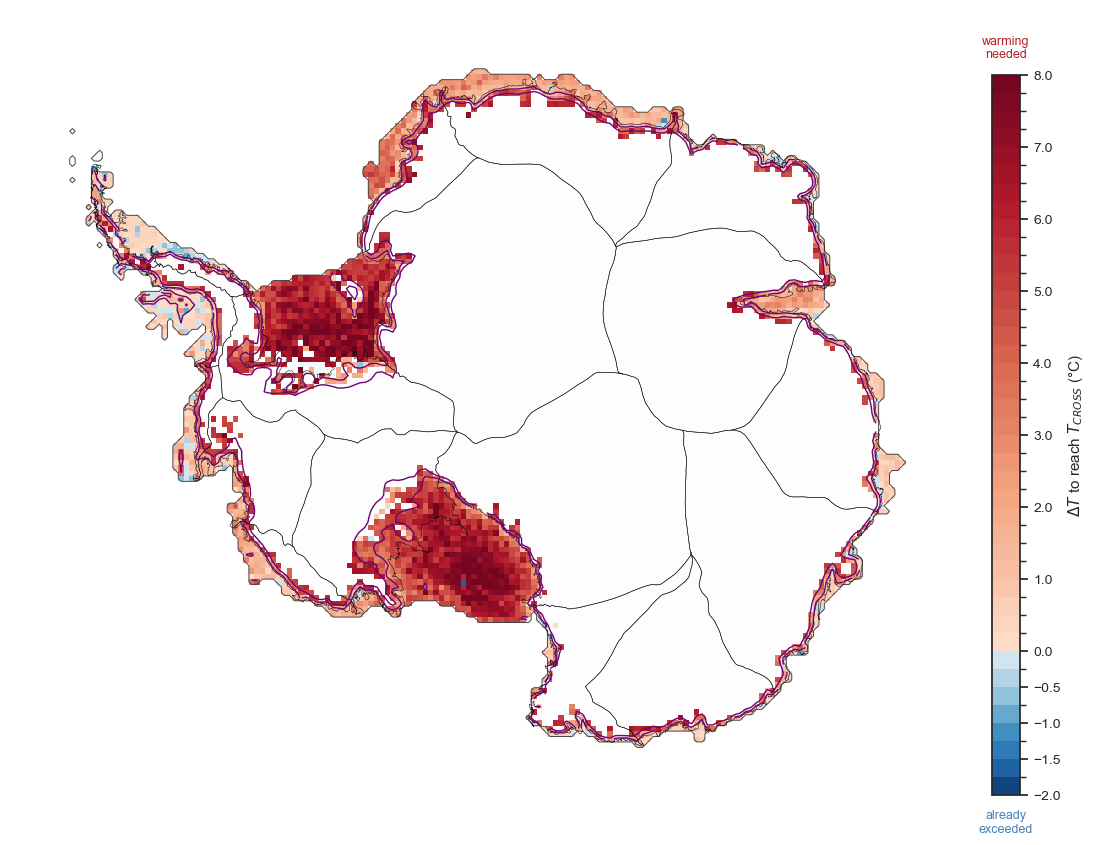

In [ ]:
SMOOTH_TCROSS = 0          # years of centred rolling mean before the crossing test
TCROSS_RU_MIN = 1.0        # kg m-2 yr-1, ignores negligible runoff
TMOA_MODE = "anomaly"      # "anomaly" (comparable with T_CROSS) or "absolute"
LABEL_BASINS = False


def tt_at_moa(ds, mode="anomaly", threshold=MOA_THRESHOLD, smooth=0):
    moa = moa_ratio(ds)
    tt = flat(ds["TT"])
    if mode == "anomaly":
        tt = tt - tt.sel(TIME=slice(REF0, REF1)).mean("TIME")
    if smooth:
        moa = moa.rolling(TIME=smooth, center=True, min_periods=1).mean()
        tt = tt.rolling(TIME=smooth, center=True, min_periods=1).mean()
    moa, tt = moa.load(), tt.load()
    exceed = moa >= threshold
    return tt.isel(TIME=exceed.argmax("TIME")).where(exceed.any("TIME")).squeeze(drop=True)


def tt_at_tcross(dsD, dsN, ru_min=TCROSS_RU_MIN, smooth=SMOOTH_TCROSS):
    """Warming at which runoff first overtakes snow transport (wind-driven snow), per pixel."""
    ru = flat(dsD["RU"])
    precip = flat(dsN["SF"]) + flat(dsN["RF"])
    transport = precip - (flat(dsD["SF"]) + flat(dsD["RF"]) - flat(dsD["ER"]))
    tt = tt_anomaly(dsD)
    if smooth:
        ru, transport, tt = (d.rolling(TIME=smooth, center=True, min_periods=1).mean()
                             for d in (ru, transport, tt))
    ru, transport, precip, tt = ru.load(), transport.load(), precip.load(), tt.load()
    exceed = (ru > transport) & (ru > ru_min) & (precip > 0)
    return tt.isel(TIME=exceed.argmax("TIME")).where(exceed.any("TIME")).squeeze(drop=True)


def ensemble_mean(fields, name=""):
    stack = []
    for m, field in fields.items():
        a = np.asarray(field.transpose("Y", "X"), dtype=float)
        a[~ais_mask] = np.nan
        a[lsm] = np.nan
        stack.append(a)
        fin = np.isfinite(a)
        print(f"{name}{m:5s}  crossed {fin.sum():5d} px   "
              f"already exceeded {int((a[fin] < 0).sum()):5d} px   "
              f"median {np.nanmedian(a):+.2f}")
    return np.nanmean(np.stack(stack), axis=0)



_base = plt.get_cmap("RdBu_r")
_neg = [_base(0.04 + 0.36 * i / 7) for i in range(8)]
_pos = [_base(0.60 + 0.38 * i / 31) for i in range(32)]
CMAP_DT = LinearSegmentedColormap.from_list("dt_div", _neg + _pos, N=40)
CMAP_DT.set_bad("none")
NORM_DT = mpl.colors.BoundaryNorm(
    np.concatenate([np.linspace(-2, 0, 9), np.linspace(0, 8, 33)[1:]]), ncolors=40)
TICKS_DT = np.concatenate([np.arange(-2, 0, 0.5), np.arange(0, 9, 1)])

CMAP_ABS = plt.get_cmap("Blues", 40).copy()
CMAP_ABS.set_bad("none")
NORM_ABS = mpl.colors.BoundaryNorm(np.linspace(-30, 0, 41), ncolors=40)
TICKS_ABS = np.arange(-30, 1, 5)


def draw_map(field, cmap, norm, ticks, label, out, annotate=True):
    fig, ax = plt.subplots(figsize=(13, 12))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.pcolormesh(x2m, y2m, np.where(GROUND, 1.0, np.nan),
                  shading="auto", cmap="Greys", vmin=0, vmax=8, alpha=0.12)
    ax.pcolormesh(x2m, y2m, np.where(SHELF, 1.0, np.nan),
                  shading="auto", cmap="Blues", vmin=0, vmax=4, alpha=0.18)

    finite = np.isfinite(field)
    pm = ax.pcolormesh(x2m, y2m, ma.array(field, mask=~finite),
                       cmap=cmap, norm=norm, shading="auto", rasterized=True, zorder=3)

    ax.contour(x2m, y2m, ICE.astype(float), levels=[0.5],
               colors="#464444", linewidths=0.7, zorder=4)
    ax.contour(x2m, y2m, topo_grd, levels=list(BAND),
               colors="#6a0572", linewidths=1.0, zorder=9)
    gdf.boundary.plot(ax=ax, color="black", linewidth=0.4, alpha=0.85, zorder=5)
    if LABEL_BASINS:
        for _, row in gdf.iterrows():
            c = row.geometry.centroid
            ax.text(c.x, c.y, row["Subregion"], fontsize=6, ha="center", va="center",
                    color="black", fontweight="bold", zorder=6)

    cax = fig.add_axes([0.88, 0.18, 0.022, 0.60])
    cb = fig.colorbar(pm, cax=cax, ticks=ticks)
    cb.set_label(label, fontsize=11)
    cb.ax.tick_params(labelsize=10)
    if annotate:
        cb.ax.text(0.5, 1.02, "warming\nneeded", ha="center", va="bottom",
                   fontsize=9, transform=cb.ax.transAxes, color="firebrick")
        cb.ax.text(0.5, -0.02, "already\nexceeded", ha="center", va="top",
                   fontsize=9, transform=cb.ax.transAxes, color="steelblue")

    ax.set_aspect("equal")
    ax.axis("off")
    plt.subplots_adjust(right=0.86, top=0.97, bottom=0.03)
    fig.savefig(out, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()


tmoa_map = ensemble_mean({m: tt_at_moa(DS[m], mode=TMOA_MODE) for m in MODELS}, "T_MOA  ")
tcross_map = ensemble_mean({m: tt_at_tcross(DS[m], NDS[m]) for m in MODELS}, "T_CROSS ")

if TMOA_MODE == "anomaly":
    draw_map(tmoa_map, CMAP_DT, NORM_DT, TICKS_DT,
             r"$\Delta T$ to reach $T_{MOA}$ (°C)", FIG_DIR / "fig4a_tmoa_map.png")
else:
    draw_map(tmoa_map, CMAP_ABS, NORM_ABS, TICKS_ABS,
             f"Absolute TT at MOA = {MOA_THRESHOLD} (°C)",
             FIG_DIR / "fig4a_tmoa_map.png", annotate=False)

draw_map(tcross_map, CMAP_DT, NORM_DT, TICKS_DT,
         r"$\Delta T$ to reach $T_{CROSS}$ (°C)", FIG_DIR / "fig4b_tcross_map.png")

#### Figure 3 effect of wind-driven on the MOA thresholds

T_MOA recomputed with the wind-driven scheme off (nDS here or mentioned nWDS in the paper), and the difference.

- DS:  MOA = (ME + RF) / (SF - ER - SU)  wind-driven scheme on  (WDS)
- nDS: MOA = (ME + RF) / (SF - SU)       wind-drivem scheme off (nWDS)

In [20]:
COMMON_TREF = False        # True measures both runs against the DS reference climate
RISK_THRESHOLD = 6.0 

def threshold_run(run):
    """Per-basin, per-model T_MOA and the reference-to-future change in each MOA term."""
    rows = []
    for basin in present:
        w = weights(basin)
        for m in MODELS:
            ds = DS[m] if run == "DS" else NDS[m]
            x = aw_mean(tt_anomaly(ds, ref=DS[m] if COMMON_TREF else None), w)
            num, den = moa_num(ds), moa_den(ds, run)
            y_num, y_den = aw_mean(num, w), aw_mean(den, w)
            ok = np.isfinite(x) & np.isfinite(y_num) & np.isfinite(y_den)

            fit = fit_wessem(x[ok], y_num[ok], y_den[ok]) if ok.sum() >= 10 else None
            change = {}
            for key, term in (("dA", den), ("dME", num)):
                ref = np.nanmean(aw_mean(term.sel(TIME=slice(REF0, REF1)), w))
                fut = np.nanmean(aw_mean(term.sel(TIME=slice(FUT0, FUT1)), w))
                change[key] = fut - ref

            rows.append({"run": run, "basin": basin, "model": m,
                         "T_MOA": fit["T_moa"] if fit else np.nan, **change})

    long = pd.DataFrame(rows)
    t = long.groupby("basin")["T_MOA"]
    summary = pd.DataFrame({"T_MOA_mean": t.mean(), "T_MOA_min": t.min(),
                            "T_MOA_max": t.max(), "n_reach": t.count()}).reset_index()
    summary["risk"] = np.where(
        (summary["n_reach"] == len(MODELS)) & (summary["T_MOA_max"] < RISK_THRESHOLD),
        "At risk", "Not at risk")
    return long, summary.set_index("basin").reindex(present).reset_index()


long_DS, df_DS = threshold_run("DS")
long_nDS, df_nDS = threshold_run("nDS")

for run, df in (("DS", df_DS), ("nDS", df_nDS)):
    print(f"{run:4s} at risk: {int((df['risk'] == 'At risk').sum())} of {len(df)} basins")

long_DS.to_csv(TAB_DIR / "TMOA_DS_per_model.csv", index=False)
long_nDS.to_csv(TAB_DIR / "TMOA_nDS_per_model.csv", index=False)

DS   at risk: 10 of 18 basins
nDS  at risk: 10 of 18 basins


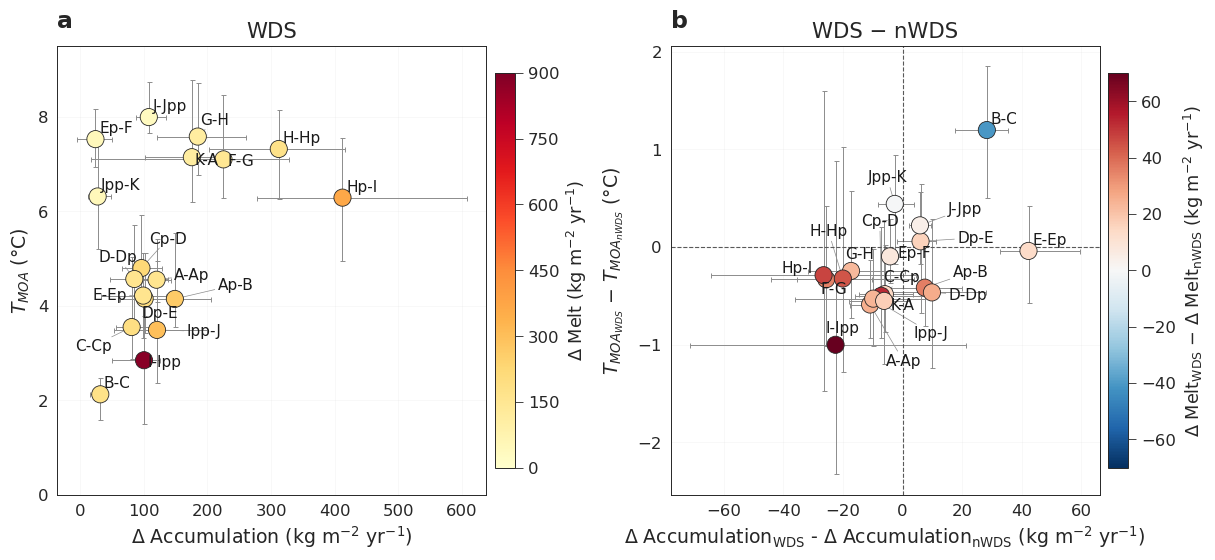

,basin,dA_mean,dA_min,dA_max,TMOA_mean,TMOA_min,TMOA_max,dME_mean,n_models
0,I-Ipp,-22.468,-71.231,21.373,-1.002,-2.328,0.876,70.076,4
1,A-Ap,-10.872,-17.750,-3.609,-0.590,-0.934,-0.130,25.666,4
2,K-A,-6.165,-17.850,2.613,-0.553,-1.200,0.276,17.328,4
3,Ipp-J,-9.826,-36.125,7.618,-0.530,-1.020,-0.017,23.954,4
4,Cp-D,-7.145,-15.925,7.708,-0.501,-0.929,0.200,52.186,4
5,C-Cp,-5.932,-14.524,3.514,-0.484,-0.867,0.023,14.413,4
6,D-Dp,9.873,-5.242,28.149,-0.466,-1.244,0.291,26.107,4
7,Ap-B,7.507,-5.604,20.011,-0.417,-0.812,0.070,36.066,4
8,F-G,-25.611,-35.568,-10.118,-0.331,-1.018,0.421,34.515,4
9,H-Hp,-20.033,-44.114,3.795,-0.324,-1.285,1.020,44.224,4


In [21]:
SAVE_FIG = True
SCALE = 1.7
FIG_W, FIG_H = 180 / 25.4 * SCALE, 82 / 25.4 * SCALE
FS_TICK, FS_AX, FS_TITLE, FS_LAB, FS_PANEL, FS_CB = (s * SCALE for s in (7, 8, 9, 6.5, 10, 7.5))
MSIZE = 90 * SCALE
VMIN, VMAX = 0, 900        # left-panel colour range, kg m-2 yr-1

plt.rcParams["font.family"] = "DejaVu Sans"

try:
    from adjustText import adjust_text
except ImportError:
    adjust_text = None
    print("adjustText not installed — basin labels are left where they fall")


def with_errors(t):
    t["xerr_left"] = t["dA_mean"] - t["dA_min"]
    t["xerr_right"] = t["dA_max"] - t["dA_mean"]
    t["yerr_low"] = t["TMOA_mean"] - t["TMOA_min"]
    t["yerr_high"] = t["TMOA_max"] - t["TMOA_mean"]
    return t


def absolute_table(summary, long):
    spread = long.groupby("basin").agg(dA_mean=("dA", "mean"), dA_min=("dA", "min"),
                                       dA_max=("dA", "max"), dME_mean=("dME", "mean"))
    t = summary.merge(spread.reset_index(), on="basin").rename(
        columns={"T_MOA_mean": "TMOA_mean", "T_MOA_min": "TMOA_min", "T_MOA_max": "TMOA_max"})
    return with_errors(t)


def difference_table(long_ds, long_nds):
    """DS - nDS per model first, then aggregated per basin."""
    keep = ["basin", "model", "T_MOA", "dA", "dME"]
    d = long_ds[keep].merge(long_nds[keep], on=["basin", "model"], suffixes=("_DS", "_nDS"))
    d["dTMOA"] = d["T_MOA_DS"] - d["T_MOA_nDS"]
    d["ddA"] = d["dA_DS"] - d["dA_nDS"]
    d["ddME"] = d["dME_DS"] - d["dME_nDS"]
    t = d.groupby("basin").agg(
        TMOA_mean=("dTMOA", "mean"), TMOA_min=("dTMOA", "min"), TMOA_max=("dTMOA", "max"),
        dA_mean=("ddA", "mean"), dA_min=("ddA", "min"), dA_max=("ddA", "max"),
        dME_mean=("ddME", "mean"), n_models=("dTMOA", lambda s: int(np.isfinite(s).sum())),
    ).reset_index()
    return with_errors(t).dropna(subset=["TMOA_mean", "dA_mean"])


def draw_panel(ax, table, title, xlabel, cmap, norm, abs_ylim=False):
    for _, row in table.iterrows():
        ax.errorbar(row["dA_mean"], row["TMOA_mean"],
                    xerr=[[row["xerr_left"]], [row["xerr_right"]]],
                    yerr=[[row["yerr_low"]], [row["yerr_high"]]],
                    fmt="none", ecolor="0.55", elinewidth=0.7,
                    capsize=1.8, capthick=0.7, zorder=1)

    sc = ax.scatter(table["dA_mean"], table["TMOA_mean"], c=table["dME_mean"],
                    cmap=cmap, norm=norm, s=MSIZE, edgecolor="0.15",
                    linewidth=0.6, zorder=3)
    texts = [ax.text(x, y, b, fontsize=FS_LAB, color="0.1", zorder=4)
             for x, y, b in zip(table["dA_mean"], table["TMOA_mean"], table["basin"])]

    ax.set_title(title, fontsize=FS_TITLE, pad=6)
    ax.set_xlabel(xlabel, fontsize=FS_AX)
    ax.grid(alpha=0.18, linewidth=0.5)
    ax.tick_params(axis="both", labelsize=FS_TICK, width=0.6, length=3)
    for spine in ax.spines.values():
        spine.set_linewidth(0.7)
    if abs_ylim:
        ax.set_ylim(0, max(9.5, np.nanmax(table["TMOA_max"]) + 0.5))
    return sc, texts


plot_DS = absolute_table(df_DS, long_DS)
plot_diff = difference_table(long_DS, long_nDS)

norm_DS = Normalize(vmin=VMIN, vmax=VMAX)
cabs = float(np.nanmax(np.abs(plot_diff["dME_mean"])))
norm_diff = TwoSlopeNorm(vmin=-cabs, vcenter=0.0, vmax=cabs) if np.isfinite(cabs) and cabs > 0 \
    else TwoSlopeNorm(vmin=-1, vcenter=0.0, vmax=1)

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H), constrained_layout=True)

sc_DS, texts_DS = draw_panel(
    axes[0], plot_DS, "WDS", r"$\Delta$ Accumulation (kg m$^{-2}$ yr$^{-1}$)",
    "YlOrRd", norm_DS, abs_ylim=True)
axes[0].set_ylabel(r"$T_{MOA}$ (°C)", fontsize=FS_AX)

cb = fig.colorbar(sc_DS, ax=axes[0], fraction=0.046, pad=0.02)
cb.set_label(r"$\Delta$ Melt (kg m$^{-2}$ yr$^{-1}$)", fontsize=FS_CB)
cb.set_ticks(np.arange(VMIN, VMAX + 1, 150))
cb.ax.tick_params(labelsize=FS_TICK, width=0.6)
cb.outline.set_linewidth(0.7)

sc_diff, texts_diff = draw_panel(
    axes[1], plot_diff, "WDS − nWDS",
    r"$\Delta$ Accumulation$_{\mathrm{WDS}}$ - $\Delta$ Accumulation$_{\mathrm{nWDS}}$"
    r" (kg m$^{-2}$ yr$^{-1}$)",
    "RdBu_r", norm_diff)
axes[1].axhline(0, color="0.35", linestyle="--", linewidth=0.8, zorder=2)
axes[1].axvline(0, color="0.35", linestyle="--", linewidth=0.8, zorder=2)
axes[1].set_ylabel(r"$T_{MOA_{WDS}}$ $-$ $T_{MOA_{nWDS}}$ (°C)", fontsize=FS_AX, labelpad=8)

cb_diff = fig.colorbar(sc_diff, ax=axes[1], fraction=0.046, pad=0.02)
cb_diff.set_label(r"$\Delta$ Melt$_{\mathrm{WDS}}$ $-$ $\Delta$ Melt$_{\mathrm{nWDS}}$"
                  r" (kg m$^{-2}$ yr$^{-1}$)", fontsize=FS_CB)
cb_diff.ax.tick_params(labelsize=FS_TICK, width=0.6)
cb_diff.outline.set_linewidth(0.7)

for ax, letter in zip(axes, "ab"):
    ax.text(0.0, 1.03, letter, transform=ax.transAxes, fontsize=FS_PANEL,
            fontweight="bold", va="bottom", ha="left")

if adjust_text is not None:
    fig.canvas.draw()
    for ax, texts, table in ((axes[0], texts_DS, plot_DS), (axes[1], texts_diff, plot_diff)):
        adjust_text(texts, x=list(table["dA_mean"]), y=list(table["TMOA_mean"]), ax=ax,
                    arrowprops=dict(arrowstyle="-", color="0.55", lw=0.5),
                    expand=(1.2, 1.45), force_text=(0.45, 0.6), force_static=(0.25, 0.4),
                    min_arrow_len=5, max_move=(26, 26))

if SAVE_FIG:
    fig.savefig(FIG_DIR / "fig5_DS_effect_on_thresholds.png", dpi=300, bbox_inches="tight")
plt.show()

display(plot_diff[["basin", "dA_mean", "dA_min", "dA_max",
                   "TMOA_mean", "TMOA_min", "TMOA_max", "dME_mean", "n_models"]]
        .sort_values("TMOA_mean").round(3).reset_index(drop=True))

## Extended Data Figures

Effect of drifting snow on projected surface melt

Change in melt between 2071-2100 and 1981-2010, WDS minus nWDS, as a percentage of
the end-of-century (2071-2100) nWDS melt:

$$\mathrm{DS}_\% = 100\;\frac{\Delta \mathrm{ME}_\mathrm{DS} - \Delta \mathrm{ME}_\mathrm{nDS}}
{\left|\overline{\mathrm{ME}}^{\,2071-2100}_\mathrm{nDS}\right|}$$

Dots mark cells where the annual WDS − nWDS difference changes significantly at the
5% from a t-test on the two periods (future and reference): Student's where an
F-test keeps equal variances, Welch's otherwise. Grey cells are where the nWDS
reference melt is too weak.


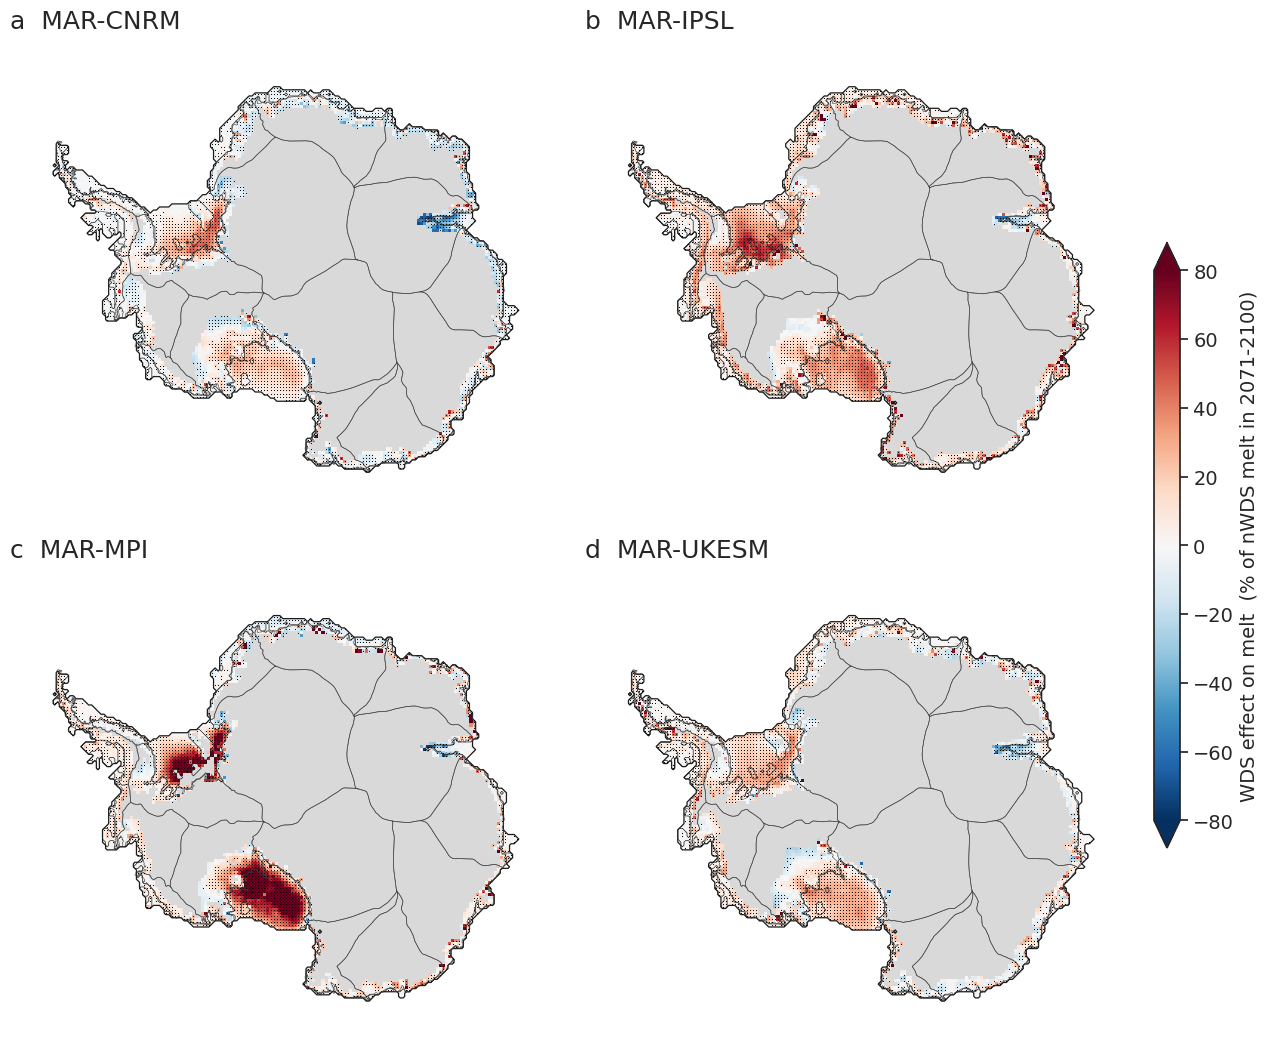

In [24]:
ALPHA = 0.05
NORMALISE = True
MIN_REF = 5.0        
VMAX = None        

plt.rcParams.update({"font.family": "sans-serif",
                     "font.sans-serif": ["DejaVu Sans"],
                     "mathtext.fontset": "dejavusans"})

ice_30 = ais_mask & (cst["ICE"].values > 30)
grd_30 = ice_30 & (cst["GROUND"].values > 30)


def welch_or_student_p(a, b):
    """Two-sided p per grid cell for two (time, y, x) samples."""
    na, nb = a.shape[0], b.shape[0]
    va, vb = a.var(axis=0, ddof=1), b.var(axis=0, ddof=1)
    diff = a.mean(axis=0) - b.mean(axis=0)

    with np.errstate(divide="ignore", invalid="ignore"):
        cdf = stats.f.cdf(va / vb, na - 1, nb - 1)
        equal_var = 2 * np.minimum(cdf, 1 - cdf) > 0.05

        pooled = ((na - 1) * va + (nb - 1) * vb) / (na + nb - 2)
        p_student = 2 * stats.t.sf(
            np.abs(diff / np.sqrt(pooled * (1 / na + 1 / nb))), na + nb - 2)

        sa, sb = va / na, vb / nb
        dof = (sa + sb) ** 2 / (sa ** 2 / (na - 1) + sb ** 2 / (nb - 1))
        p_welch = 2 * stats.t.sf(np.abs(diff / np.sqrt(sa + sb)), dof)

        p = np.where(equal_var, p_student, p_welch)
    return np.where((va > 0) & (vb > 0), p, np.nan)


def melt_windows(ds):
    me = flat(ds["ME"])
    return (me.sel(TIME=slice(REF0, REF1)).values,
            me.sel(TIME=slice(FUT0, FUT1)).values)


field, blank, significant = {}, {}, {}

for m in MODELS:
    ds_ref, ds_fut = melt_windows(DS[m])
    nds_ref, nds_fut = melt_windows(NDS[m])

    effect = np.where(ice_30,
                      (ds_fut.mean(0) - ds_ref.mean(0)) - (nds_fut.mean(0) - nds_ref.mean(0)),
                      np.nan)
    reference = np.abs(nds_fut.mean(0))

    if NORMALISE:
        usable = ice_30 & (reference >= MIN_REF)
        field[m] = np.where(usable, 100 * effect / reference, np.nan)
        blank[m] = ice_30 & ~usable
    else:
        field[m] = effect
        blank[m] = np.zeros_like(ice_30)

    p = welch_or_student_p(ds_ref - nds_ref, ds_fut - nds_fut)
    significant[m] = ice_30 & np.isfinite(p) & (p < ALPHA)

    #print(f"{LONG_NAME[m]:<11s} median effect {np.nanmedian(effect[ice_30]):6.1f} kg m-2 yr-1, "
          #f"significant on {100 * significant[m][ice_30].mean():.0f}% of the ice sheet")

pooled = np.concatenate([f[np.isfinite(f)] for f in field.values()])
vmax = VMAX or np.percentile(np.abs(pooled), 98)
vmax = 5 * np.ceil(vmax / 5) if vmax < 50 else 10 * np.ceil(vmax / 10)

label = (f"WDS effect on melt  (% of nWDS melt in {FUT0[:4]}-{FUT1[:4]})" if NORMALISE
         else r"$\Delta$ME, DS $-$ nDS  (kg m$^{-2}$ yr$^{-1}$)")
if NORMALISE:
    dropped = 100 * np.mean([blank[m][ice_30].mean() for m in MODELS])
    #print(f"reference melt below {MIN_REF:g} kg m-2 yr-1 on {dropped:.0f}% of the ice sheet")
#print(f"colour limit {vmax:.0f}")

outlines = gdf[gdf["Subregion"].str.strip() != "Islands"].geometry.simplify(2000)

fig, axes = plt.subplots(2, 2, figsize=(13, 11))

for panel, (ax, m) in enumerate(zip(axes.ravel(), MODELS)):
    if blank[m].any():
        ax.pcolormesh(x2m, y2m, np.where(blank[m], 1.0, np.nan), shading="auto",
                      cmap=mpl.colors.ListedColormap(["0.85"]), vmin=0, vmax=1, zorder=2)

    mesh = ax.pcolormesh(x2m, y2m, field[m], shading="auto", cmap="RdBu_r",
                         vmin=-vmax, vmax=vmax, zorder=3, rasterized=True)

    ax.contour(x2m, y2m, ice_30.astype(float), [0.5], colors="0.1", linewidths=0.9, zorder=7)
    ax.contour(x2m, y2m, grd_30.astype(float), [0.5], colors="0.1", linewidths=0.5, zorder=7)
    outlines.boundary.plot(ax=ax, color="0.25", lw=0.45, alpha=0.9, zorder=8)

    iy, ix = np.where(significant[m] & np.isfinite(field[m]))
    ax.scatter(x2m[iy, ix], y2m[iy, ix], s=2, c="black", marker=".", lw=0, zorder=10)

    ax.set_title(f"{chr(97 + panel)}  {LONG_NAME[m]}", fontsize=18, loc="left")
    ax.set_aspect("equal")
    ax.axis("off")

cax = fig.add_axes([0.90, 0.22, 0.02, 0.55])
cbar = fig.colorbar(mesh, cax=cax, extend="both")
cbar.set_label(label, fontsize=14)
cbar.ax.tick_params(labelsize=14)

fig.patch.set_facecolor("white")
fig.subplots_adjust(wspace=0.06, hspace=0.12, left=0.02, right=0.88, top=0.95, bottom=0.04)
#fig.savefig(FIG_DIR / "ed1_melt_DS_effect.png", dpi=300, bbox_inches="tight")
plt.show()

MAR-CNRM    melt onset reached on 50% of the ice sheet, median +0.29 °C
MAR-IPSL    melt onset reached on 46% of the ice sheet, median +0.28 °C
MAR-MPI     melt onset reached on 44% of the ice sheet, median +0.13 °C
MAR-UKESM   melt onset reached on 48% of the ice sheet, median -0.48 °C


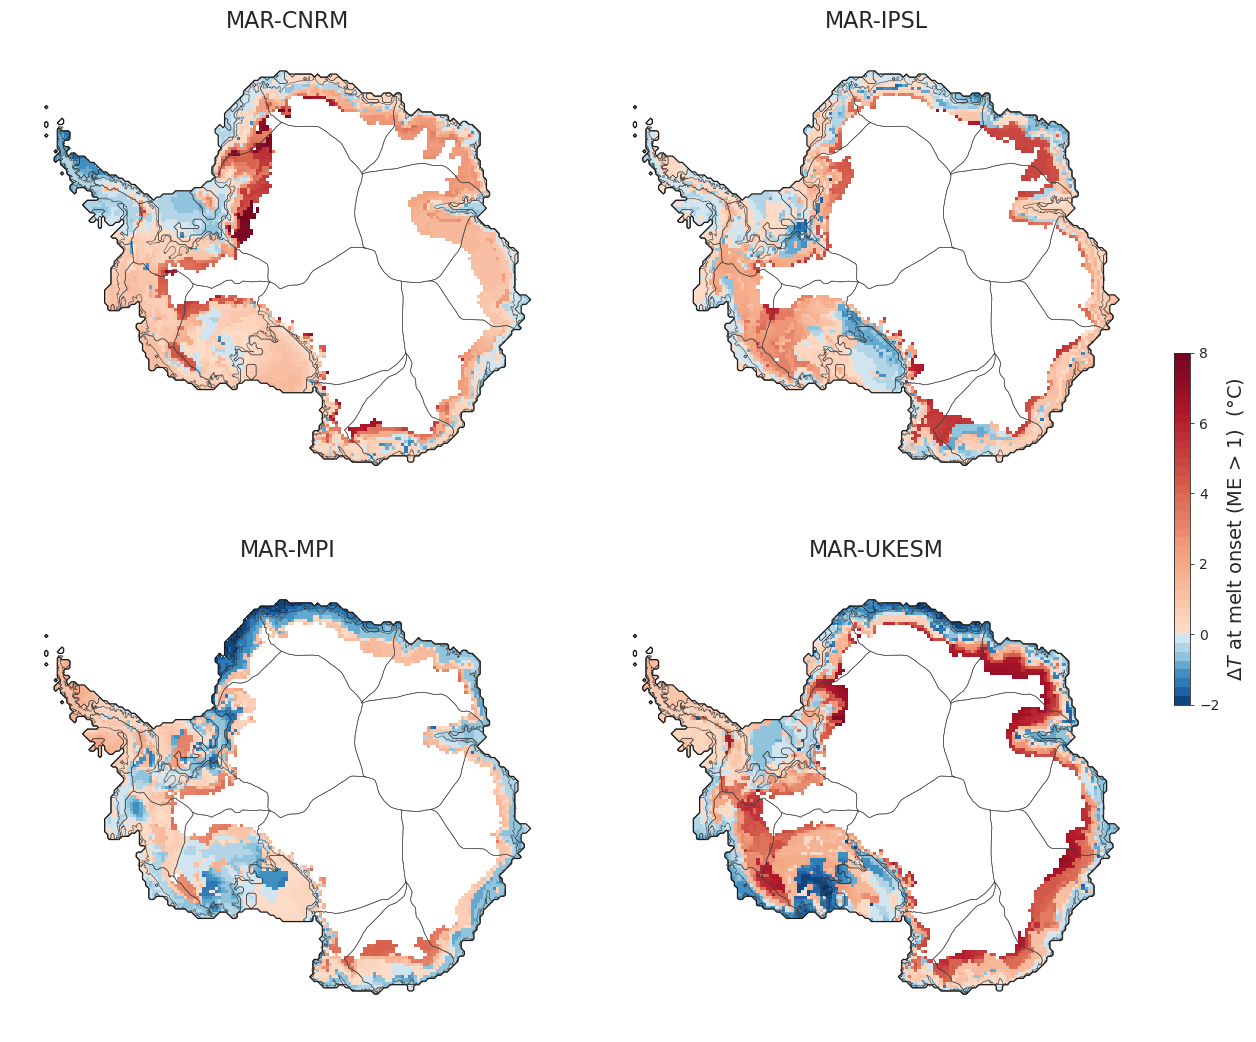

In [ ]:
ME_THRESHOLD = 1.0     # kg m-2 yr-1
SMOOTH_ONSET = 0       
TICKS_ONSET = np.arange(-2, 9, 2)

def tt_at_melt_onset(ds, threshold=ME_THRESHOLD, smooth=SMOOTH_ONSET):
    """Per-pixel warming at the first year with ME above the threshold."""
    me = flat(ds["ME"])
    tt = tt_anomaly(ds)
    if smooth:
        me = me.rolling(TIME=smooth, center=True, min_periods=1).mean()
        tt = tt.rolling(TIME=smooth, center=True, min_periods=1).mean()
    me, tt = me.load(), tt.load()
    exceed = me >= threshold
    onset = tt.isel(TIME=exceed.argmax("TIME")).where(exceed.any("TIME"))
    return np.asarray(onset.squeeze(drop=True).transpose("Y", "X"), dtype=float)


fig, axes = plt.subplots(2, 2, figsize=(13, 11))
outlines = gdf[gdf["Subregion"].str.strip() != "Islands"].geometry.simplify(2000)

for ax, m in zip(axes.ravel(), MODELS):
    z = tt_at_melt_onset(DS[m])
    masked = ma.array(z, mask=lsm | ~ais_mask | ~np.isfinite(z))
    mesh = ax.pcolormesh(x2m, y2m, masked, cmap=CMAP_DT, norm=NORM_DT,
                         shading="auto", rasterized=True, zorder=3)

    ax.contour(x2m, y2m, ICE.astype(float), [0.5], colors="0.1", linewidths=0.9, zorder=7)
    ax.contour(x2m, y2m, GROUND.astype(float), [0.5], colors="0.1", linewidths=0.5, zorder=7)
    outlines.boundary.plot(ax=ax, color="0.25", lw=0.45, alpha=0.9, zorder=8)

    ax.set_title(LONG_NAME[m], fontsize=16)
    ax.set_aspect("equal")
    ax.axis("off")
    print(f"{LONG_NAME[m]:<11s} melt onset reached on {np.isfinite(z)[ais_mask].mean() * 100:.0f}% "
          f"of the ice sheet, median {np.nanmedian(z):+.2f} °C")

cax = fig.add_axes([0.915, 0.34, 0.013, 0.32])
cbar = fig.colorbar(mesh, cax=cax, ticks=TICKS_ONSET)
cbar.set_label(rf"$\Delta T$ at melt onset (ME > {ME_THRESHOLD:g})  (°C)", fontsize=14)
cbar.ax.minorticks_off()
cbar.ax.tick_params(labelsize=10, length=3, width=0.6)
cbar.outline.set_linewidth(0.6)

fig.patch.set_facecolor("white")
plt.subplots_adjust(wspace=0.06, hspace=0.12, left=0.02, right=0.90, top=0.95, bottom=0.04)
fig.savefig(FIG_DIR / f"ed2_melt_onset_thr{ME_THRESHOLD:g}.png", dpi=200, bbox_inches="tight")
plt.show()

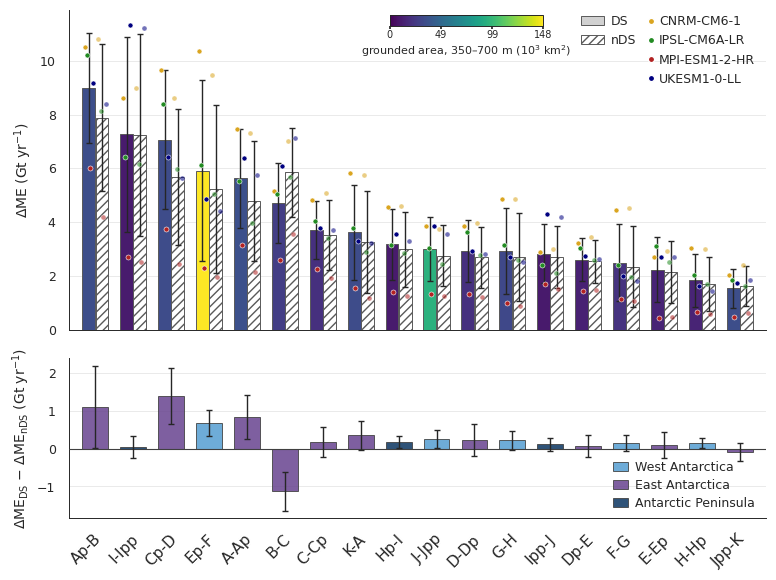

AIS total, 350-700 m:  DS 72.52  nDS 67.67  diff +4.85 Gt/yr  over 612 x10^3 km^2
basins where DS < nDS: ['B-C', 'Jpp-K']
sign-consistent across all four models: 8 of 18

AREA_2D: mean 0.988, range 0.867-1.055


,region,area_1e3km2,DS,DS_sd,nDS,nDS_sd,diff,diff_sd,pct_of_nDS
Ap-B,EAIS,34.841,8.994,2.060,7.885,2.741,1.109,1.086,14.063
I-Ipp,Peninsula,10.686,7.268,3.635,7.230,3.760,0.038,0.290,0.525
Cp-D,EAIS,33.921,7.059,2.587,5.676,2.527,1.383,0.740,24.364
Ep-F,WAIS,147.881,5.911,3.365,5.228,3.127,0.683,0.348,13.074
A-Ap,EAIS,35.984,5.633,1.841,4.796,2.234,0.837,0.585,17.460
B-C,EAIS,27.060,4.722,1.494,5.850,1.668,-1.128,0.521,-19.275
C-Cp,EAIS,20.274,3.720,1.075,3.536,1.300,0.183,0.397,5.184
K-A,EAIS,33.865,3.620,1.760,3.263,1.887,0.358,0.383,10.958
Hp-I,Peninsula,10.876,3.172,1.328,3.000,1.395,0.173,0.157,5.755
J-Jpp,WAIS,94.185,3.012,1.192,2.758,1.151,0.254,0.248,9.205


,area_1e3km2,DS,nDS,diff,pct_of_nDS,n_basins
region,,,,,,
WAIS,310.161,16.195,14.721,1.474,10.013,5
EAIS,270.168,43.055,40.012,3.043,7.605,10
Peninsula,31.551,13.266,12.936,0.329,2.545,3


In [ ]:
LABELS = {"CNRM": "CNRM-CM6-1", "IPSL": "IPSL-CM6A-LR",
          "MPI": "MPI-ESM1-2-HR", "UKM": "UKESM1-0-LL"}
REGION = {
    "K-A": "EAIS", "A-Ap": "EAIS", "Ap-B": "EAIS", "Jpp-K": "EAIS",
    "B-C": "EAIS", "E-Ep": "EAIS", "C-Cp": "EAIS", "Cp-D": "EAIS",
    "Dp-E": "EAIS", "D-Dp": "EAIS",
    "H-Hp": "WAIS", "J-Jpp": "WAIS", "G-H": "WAIS", "F-G": "WAIS", "Ep-F": "WAIS",
    "I-Ipp": "Peninsula", "Ipp-J": "Peninsula", "Hp-I": "Peninsula",
}
REGION_COLORS = {"WAIS": "#559ED2", "EAIS": "#68438F", "Peninsula": "#0A3561"}
REGION_LABELS = {"WAIS": "West Antarctica", "EAIS": "East Antarctica",
                 "Peninsula": "Antarctic Peninsula"}
REGION_ORDER = ["WAIS", "EAIS", "Peninsula"]

HIGHLIGHT = None          # e.g. "B-C"
SORT_BY = "DS"            # "DS" | "nDS" | "diff" | None
DOTS = "both"             # "both" | "ds" | "none"
FIGSIZE = (9.0, 6.6)
XTICK_SHIFT_PT = 6
AREA_CMAP = "viridis"
C_NDS = "white"
DIFF_ALPHA = 0.85

import matplotlib.transforms as mtransforms
from matplotlib import cm
from matplotlib.lines import Line2D

PIXEL_KM2 = (RESOLUTION / 1000) ** 2
GT_PER_KGM2 = RESOLUTION ** 2 / 1e12   

missing = sorted(set(present) - set(REGION))
if missing:
    raise ValueError(f"no region assigned for: {missing}")

rows, area = [], {}
for basin in present:
    w = weights(basin)
    area[basin] = float(np.nansum(w)) * PIXEL_KM2 / 1e3      # 10^3 km2
    for run, runs in (("DS", DS), ("nDS", NDS)):
        for m in MODELS:
            me = flat(runs[m]["ME"])
            ref = np.nanmean(aw_mean(me.sel(TIME=slice(REF0, REF1)), w))
            fut = np.nanmean(aw_mean(me.sel(TIME=slice(FUT0, FUT1)), w))
            rows.append({"run": run, "basin": basin, "model": m,
                         "dME_Gtyr": (fut - ref) * np.nansum(w) * GT_PER_KGM2})

raw = pd.DataFrame(rows)
wide = {run: raw[raw["run"] == run].pivot(index="basin", columns="model", values="dME_Gtyr")
             .reindex(index=present, columns=list(MODELS))
        for run in ("DS", "nDS")}
for run, df in wide.items():
    df["mean"] = df[list(MODELS)].mean(axis=1)
    df["std"] = df[list(MODELS)].std(axis=1, ddof=1)

ds_tab, nds_tab = wide["DS"], wide["nDS"]
diff = ds_tab[list(MODELS)] - nds_tab[list(MODELS)]     # paired by forcing
diff_mean, diff_std = diff.mean(axis=1), diff.std(axis=1, ddof=1)

order = {"DS": ds_tab["mean"], "nDS": nds_tab["mean"], "diff": diff_mean}.get(SORT_BY)
if order is not None:
    idx = order.sort_values(ascending=False).index
    ds_tab, nds_tab, diff = ds_tab.loc[idx], nds_tab.loc[idx], diff.loc[idx]
    diff_mean, diff_std = diff_mean.loc[idx], diff_std.loc[idx]

basins = list(ds_tab.index)
x = np.arange(len(basins))
area = pd.Series(area).reindex(basins)

area_cmap = LinearSegmentedColormap.from_list(
    "area_clip", plt.get_cmap(AREA_CMAP)(np.linspace(0, 1, 256)))
area_norm = Normalize(vmin=0.0, vmax=float(area.max()))

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 7,
                     "axes.linewidth": 0.7,
                     "xtick.direction": "out", "ytick.direction": "out"})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=FIGSIZE, sharex=True,
                               gridspec_kw={"height_ratios": [2.0, 1.0], "hspace": 0.12})

w_bar, off = 0.34, 0.175
bars_ds = ax1.bar(x - off, ds_tab["mean"], width=w_bar,
                  color=[area_cmap(area_norm(v)) for v in area],
                  edgecolor="0.35", linewidth=0.7, zorder=2)
bars_nds = ax1.bar(x + off, nds_tab["mean"], width=w_bar, color=C_NDS,
                   edgecolor="0.35", linewidth=0.7, hatch="////", zorder=3)

for sign, tab in ((-off, ds_tab), (off, nds_tab)):
    ax1.errorbar(x + sign, tab["mean"], yerr=tab["std"], fmt="none", ecolor="0.15",
                 elinewidth=1.0, capsize=2.5, capthick=1.0, zorder=5)

if DOTS != "none":
    jit = np.linspace(-0.10, 0.10, len(MODELS))
    for i, m in enumerate(MODELS):
        ax1.scatter(x - off + jit[i], ds_tab[m], s=13, color=MODELS[m],
                    edgecolor="white", linewidth=0.4, zorder=6)
        if DOTS == "both":
            ax1.scatter(x + off + jit[i], nds_tab[m], s=13, color=MODELS[m],
                        edgecolor="white", linewidth=0.4, alpha=0.55, zorder=6)

if HIGHLIGHT in basins:
    for bar in (bars_ds[basins.index(HIGHLIGHT)], bars_nds[basins.index(HIGHLIGHT)]):
        bar.set_edgecolor("black")
        bar.set_linewidth(1.5)

ax1.set_ylabel(r"$\Delta$ME (Gt yr$^{-1}$)", fontsize=10)
ax1.set_ylim(0, None)

ax2.bar(x, diff_mean, width=0.68, color=[REGION_COLORS[REGION[b]] for b in basins],
        edgecolor="0.25", linewidth=0.7, alpha=DIFF_ALPHA, zorder=2)
ax2.errorbar(x, diff_mean, yerr=diff_std, fmt="none", ecolor="0.15",
             elinewidth=1.0, capsize=2.5, capthick=1.0, zorder=4)
ax2.axhline(0, color="0.25", linewidth=0.8, zorder=3)
ax2.set_ylabel(r"$\Delta$ME$_{\mathrm{DS}}$ $-$ $\Delta$ME$_{\mathrm{nDS}}$ (Gt yr$^{-1}$)",
               fontsize=10)

ax2.set_xticks(x)
ax2.set_xticklabels(basins, rotation=45, ha="right", fontsize=11)
shift = mtransforms.ScaledTranslation(XTICK_SHIFT_PT / 72, 0, fig.dpi_scale_trans)
for lbl in ax2.get_xticklabels():
    lbl.set_transform(lbl.get_transform() + shift)
ax2.set_xlim(-0.7, len(basins) - 0.3)

for ax in (ax1, ax2):
    ax.grid(axis="y", color="0.9", linewidth=0.6, zorder=0)
    ax.tick_params(axis="y", labelsize=9)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

leg_runs = ax1.legend(
    handles=[Patch(facecolor="0.82", edgecolor="0.35", linewidth=0.7, label="DS"),
             Patch(facecolor=C_NDS, edgecolor="0.35", linewidth=0.7,
                   hatch="////", label="nDS")],
    frameon=False, fontsize=9, loc="upper right", bbox_to_anchor=(0.83, 1.02),
    handletextpad=0.6, handlelength=1.8, labelspacing=0.5)
ax1.legend(handles=[Line2D([], [], marker="o", linestyle="none", markersize=4.5,
                           markerfacecolor=c, markeredgecolor="white", label=LABELS[m])
                    for m, c in MODELS.items()],
           frameon=False, fontsize=9, loc="upper right", bbox_to_anchor=(1.00, 1.02),
           handletextpad=0.6, handlelength=0, labelspacing=0.5)
ax1.add_artist(leg_runs)

ax2.legend(handles=[Patch(facecolor=REGION_COLORS[r], edgecolor="0.25", linewidth=0.7,
                          alpha=DIFF_ALPHA, label=REGION_LABELS[r]) for r in REGION_ORDER],
           frameon=False, fontsize=9, loc="lower right", bbox_to_anchor=(1.00, -0.02),
           handletextpad=0.6, handlelength=1.2, labelspacing=0.4)

cax = ax1.inset_axes([0.46, 0.95, 0.22, 0.035])
cb = fig.colorbar(cm.ScalarMappable(norm=area_norm, cmap=area_cmap),
                  cax=cax, orientation="horizontal")
cb.set_label(r"grounded area, 350–700 m ($10^3$ km$^2$)", fontsize=8, labelpad=2)
cb.ax.tick_params(labelsize=7, length=2, pad=1)
cb.set_ticks(np.linspace(0, float(area.max()), 4).round(0))

fig.savefig(FIG_DIR / "ed3_dME_per_basin_DS_nDS.png", dpi=300, bbox_inches="tight")
plt.show()
plt.rcParams.update({"font.size": 10})     

tab = pd.DataFrame({"region": [REGION[b] for b in basins], "area_1e3km2": area,
                    "DS": ds_tab["mean"], "DS_sd": ds_tab["std"],
                    "nDS": nds_tab["mean"], "nDS_sd": nds_tab["std"],
                    "diff": diff_mean, "diff_sd": diff_std})
tab["pct_of_nDS"] = 100 * tab["diff"] / tab["nDS"]
totals = tab.groupby("region")[["area_1e3km2", "DS", "nDS", "diff"]].sum()
totals["pct_of_nDS"] = 100 * totals["diff"] / totals["nDS"]
totals["n_basins"] = tab.groupby("region").size()

print(f"AIS total, {BAND[0]}-{BAND[1]} m:  DS {ds_tab['mean'].sum():.2f}  "
      f"nDS {nds_tab['mean'].sum():.2f}  diff {diff_mean.sum():+.2f} Gt/yr  "
      f"over {area.sum():.0f} x10^3 km^2")
print("basins where DS < nDS:", list(tab.index[tab["diff"] < 0]) or "none")
print(f"sign-consistent across all four models: "
      f"{int(((diff > 0).all(axis=1) | (diff < 0).all(axis=1)).sum())} of {len(diff)}")
print(f"\nAREA_2D: mean {AREA_2D.mean():.3f}, range {AREA_2D.min():.3f}-{AREA_2D.max():.3f}")
display(tab.round(3))
display(totals.reindex(REGION_ORDER).round(3))

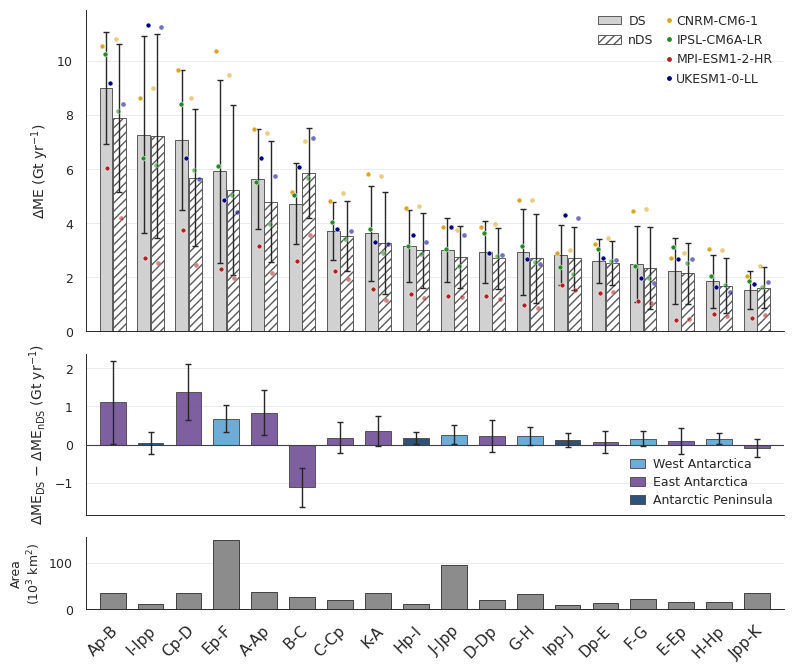

AIS total, 350-700 m:  DS 72.52  nDS 67.67  diff +4.85 Gt/yr  over 612 x10^3 km^2
basins where DS < nDS: ['B-C', 'Jpp-K']
sign-consistent across all four models: 8 of 18

AREA_2D: mean 0.988, range 0.867-1.055


,region,area_1e3km2,DS,DS_sd,nDS,nDS_sd,diff,diff_sd,pct_of_nDS
Ap-B,EAIS,34.841,8.994,2.060,7.885,2.741,1.109,1.086,14.063
I-Ipp,Peninsula,10.686,7.268,3.635,7.230,3.760,0.038,0.290,0.525
Cp-D,EAIS,33.921,7.059,2.587,5.676,2.527,1.383,0.740,24.364
Ep-F,WAIS,147.881,5.911,3.365,5.228,3.127,0.683,0.348,13.074
A-Ap,EAIS,35.984,5.633,1.841,4.796,2.234,0.837,0.585,17.460
B-C,EAIS,27.060,4.722,1.494,5.850,1.668,-1.128,0.521,-19.275
C-Cp,EAIS,20.274,3.720,1.075,3.536,1.300,0.183,0.397,5.184
K-A,EAIS,33.865,3.620,1.760,3.263,1.887,0.358,0.383,10.958
Hp-I,Peninsula,10.876,3.172,1.328,3.000,1.395,0.173,0.157,5.755
J-Jpp,WAIS,94.185,3.012,1.192,2.758,1.151,0.254,0.248,9.205


,area_1e3km2,DS,nDS,diff,pct_of_nDS,n_basins
region,,,,,,
WAIS,310.161,16.195,14.721,1.474,10.013,5
EAIS,270.168,43.055,40.012,3.043,7.605,10
Peninsula,31.551,13.266,12.936,0.329,2.545,3


In [34]:
LABELS = {"CNRM": "CNRM-CM6-1", "IPSL": "IPSL-CM6A-LR",
          "MPI": "MPI-ESM1-2-HR", "UKM": "UKESM1-0-LL"}
REGION = {
    "K-A": "EAIS", "A-Ap": "EAIS", "Ap-B": "EAIS", "Jpp-K": "EAIS",
    "B-C": "EAIS", "E-Ep": "EAIS", "C-Cp": "EAIS", "Cp-D": "EAIS",
    "Dp-E": "EAIS", "D-Dp": "EAIS",
    "H-Hp": "WAIS", "J-Jpp": "WAIS", "G-H": "WAIS", "F-G": "WAIS", "Ep-F": "WAIS",
    "I-Ipp": "Peninsula", "Ipp-J": "Peninsula", "Hp-I": "Peninsula",
}
REGION_COLORS = {"WAIS": "#559ED2", "EAIS": "#68438F", "Peninsula": "#0A3561"}
REGION_LABELS = {"WAIS": "West Antarctica", "EAIS": "East Antarctica",
                 "Peninsula": "Antarctic Peninsula"}
REGION_ORDER = ["WAIS", "EAIS", "Peninsula"]

HIGHLIGHT = None          # e.g. "B-C"
SORT_BY = "DS"            # "DS" | "nDS" | "diff" | None
DOTS = "both"             # "both" | "ds" | "none"
FIGSIZE = (9.0, 6.6)
XTICK_SHIFT_PT = 6
#AREA_CMAP = "viridis"
C_NDS = "white"
DIFF_ALPHA = 0.85

import matplotlib.transforms as mtransforms
#from matplotlib import cm
from matplotlib.lines import Line2D

PIXEL_KM2 = (RESOLUTION / 1000) ** 2
GT_PER_KGM2 = RESOLUTION ** 2 / 1e12   

missing = sorted(set(present) - set(REGION))
if missing:
    raise ValueError(f"no region assigned for: {missing}")

rows, area = [], {}
for basin in present:
    w = weights(basin)
    area[basin] = float(np.nansum(w)) * PIXEL_KM2 / 1e3      # 10^3 km2
    for run, runs in (("DS", DS), ("nDS", NDS)):
        for m in MODELS:
            me = flat(runs[m]["ME"])
            ref = np.nanmean(aw_mean(me.sel(TIME=slice(REF0, REF1)), w))
            fut = np.nanmean(aw_mean(me.sel(TIME=slice(FUT0, FUT1)), w))
            rows.append({"run": run, "basin": basin, "model": m,
                         "dME_Gtyr": (fut - ref) * np.nansum(w) * GT_PER_KGM2})

raw = pd.DataFrame(rows)
wide = {run: raw[raw["run"] == run].pivot(index="basin", columns="model", values="dME_Gtyr")
             .reindex(index=present, columns=list(MODELS))
        for run in ("DS", "nDS")}
for run, df in wide.items():
    df["mean"] = df[list(MODELS)].mean(axis=1)
    df["std"] = df[list(MODELS)].std(axis=1, ddof=1)

ds_tab, nds_tab = wide["DS"], wide["nDS"]
diff = ds_tab[list(MODELS)] - nds_tab[list(MODELS)]     # paired by forcing
diff_mean, diff_std = diff.mean(axis=1), diff.std(axis=1, ddof=1)

order = {"DS": ds_tab["mean"], "nDS": nds_tab["mean"], "diff": diff_mean}.get(SORT_BY)
if order is not None:
    idx = order.sort_values(ascending=False).index
    ds_tab, nds_tab, diff = ds_tab.loc[idx], nds_tab.loc[idx], diff.loc[idx]
    diff_mean, diff_std = diff_mean.loc[idx], diff_std.loc[idx]

basins = list(ds_tab.index)
x = np.arange(len(basins))
area = pd.Series(area).reindex(basins)



plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 7,
                     "axes.linewidth": 0.7,
                     "xtick.direction": "out", "ytick.direction": "out"})

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(FIGSIZE[0], FIGSIZE[1] * 1.18), sharex=True,
    gridspec_kw={"height_ratios": [2.0, 1.0, 0.45], "hspace": 0.12})

w_bar, off = 0.34, 0.175
bars_ds = ax1.bar(x - off, ds_tab["mean"], width=w_bar, color="0.82",
                  edgecolor="0.35", linewidth=0.7, zorder=2)

bars_nds = ax1.bar(x + off, nds_tab["mean"], width=w_bar, color=C_NDS,
                   edgecolor="0.35", linewidth=0.7, hatch="////", zorder=3)

for sign, tab in ((-off, ds_tab), (off, nds_tab)):
    ax1.errorbar(x + sign, tab["mean"], yerr=tab["std"], fmt="none", ecolor="0.15",
                 elinewidth=1.0, capsize=2.5, capthick=1.0, zorder=5)

if DOTS != "none":
    jit = np.linspace(-0.10, 0.10, len(MODELS))
    for i, m in enumerate(MODELS):
        ax1.scatter(x - off + jit[i], ds_tab[m], s=13, color=MODELS[m],
                    edgecolor="white", linewidth=0.4, zorder=6)
        if DOTS == "both":
            ax1.scatter(x + off + jit[i], nds_tab[m], s=13, color=MODELS[m],
                        edgecolor="white", linewidth=0.4, alpha=0.55, zorder=6)

if HIGHLIGHT in basins:
    for bar in (bars_ds[basins.index(HIGHLIGHT)], bars_nds[basins.index(HIGHLIGHT)]):
        bar.set_edgecolor("black")
        bar.set_linewidth(1.5)

ax1.set_ylabel(r"$\Delta$ME (Gt yr$^{-1}$)", fontsize=10)
ax1.set_ylim(0, None)

ax2.bar(x, diff_mean, width=0.68, color=[REGION_COLORS[REGION[b]] for b in basins],
        edgecolor="0.25", linewidth=0.7, alpha=DIFF_ALPHA, zorder=2)
ax2.errorbar(x, diff_mean, yerr=diff_std, fmt="none", ecolor="0.15",
             elinewidth=1.0, capsize=2.5, capthick=1.0, zorder=4)
ax2.axhline(0, color="0.25", linewidth=0.8, zorder=3)
ax2.set_ylabel(r"$\Delta$ME$_{\mathrm{DS}}$ $-$ $\Delta$ME$_{\mathrm{nDS}}$ (Gt yr$^{-1}$)",
               fontsize=10)

ax3.set_xticks(x)
ax3.set_xticklabels(basins, rotation=45, ha="right", fontsize=11)
shift = mtransforms.ScaledTranslation(XTICK_SHIFT_PT / 72, 0, fig.dpi_scale_trans)
for lbl in ax3.get_xticklabels():
    lbl.set_transform(lbl.get_transform() + shift)
ax3.set_xlim(-0.7, len(basins) - 0.3)

for ax in (ax1, ax2, ax3):
    ax.grid(axis="y", color="0.9", linewidth=0.6, zorder=0)
    ax.tick_params(axis="y", labelsize=9)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

leg_runs = ax1.legend(
    handles=[Patch(facecolor="0.82", edgecolor="0.35", linewidth=0.7, label="DS"),
             Patch(facecolor=C_NDS, edgecolor="0.35", linewidth=0.7,
                   hatch="////", label="nDS")],
    frameon=False, fontsize=9, loc="upper right", bbox_to_anchor=(0.83, 1.02),
    handletextpad=0.6, handlelength=1.8, labelspacing=0.5)
ax1.legend(handles=[Line2D([], [], marker="o", linestyle="none", markersize=4.5,
                           markerfacecolor=c, markeredgecolor="white", label=LABELS[m])
                    for m, c in MODELS.items()],
           frameon=False, fontsize=9, loc="upper right", bbox_to_anchor=(1.00, 1.02),
           handletextpad=0.6, handlelength=0, labelspacing=0.5)
ax1.add_artist(leg_runs)

ax2.legend(handles=[Patch(facecolor=REGION_COLORS[r], edgecolor="0.25", linewidth=0.7,
                          alpha=DIFF_ALPHA, label=REGION_LABELS[r]) for r in REGION_ORDER],
           frameon=False, fontsize=9, loc="lower right", bbox_to_anchor=(1.00, -0.02),
           handletextpad=0.6, handlelength=1.2, labelspacing=0.4)

ax3.bar(x, area, width=0.68, color="0.55", edgecolor="0.25", linewidth=0.7, zorder=2)
ax3.set_ylabel("Area\n($10^3$ km$^2$)", fontsize=9)
ax3.set_ylim(0, None)

fig.savefig(FIG_DIR / "ed3_dME_per_basin_DS_nDS.png", dpi=300, bbox_inches="tight")
plt.show()
plt.rcParams.update({"font.size": 10})     

tab = pd.DataFrame({"region": [REGION[b] for b in basins], "area_1e3km2": area,
                    "DS": ds_tab["mean"], "DS_sd": ds_tab["std"],
                    "nDS": nds_tab["mean"], "nDS_sd": nds_tab["std"],
                    "diff": diff_mean, "diff_sd": diff_std})
tab["pct_of_nDS"] = 100 * tab["diff"] / tab["nDS"]
totals = tab.groupby("region")[["area_1e3km2", "DS", "nDS", "diff"]].sum()
totals["pct_of_nDS"] = 100 * totals["diff"] / totals["nDS"]
totals["n_basins"] = tab.groupby("region").size()

print(f"AIS total, {BAND[0]}-{BAND[1]} m:  DS {ds_tab['mean'].sum():.2f}  "
      f"nDS {nds_tab['mean'].sum():.2f}  diff {diff_mean.sum():+.2f} Gt/yr  "
      f"over {area.sum():.0f} x10^3 km^2")
print("basins where DS < nDS:", list(tab.index[tab["diff"] < 0]) or "none")
print(f"sign-consistent across all four models: "
      f"{int(((diff > 0).all(axis=1) | (diff < 0).all(axis=1)).sum())} of {len(diff)}")
print(f"\nAREA_2D: mean {AREA_2D.mean():.3f}, range {AREA_2D.min():.3f}-{AREA_2D.max():.3f}")
display(tab.round(3))
display(totals.reindex(REGION_ORDER).round(3))

AREA check: mean cell 0.9884, AIS total 1.149e+04 (km2 if the total is around 1.4e7)
Grounded ice  WAIS        ΔT -0.70 to +5.05 °C   melt area  14.64 →  48.08 %
Grounded ice  EAIS        ΔT -0.78 to +5.95 °C   melt area   4.61 →  15.32 %
Grounded ice  Peninsula   ΔT -0.56 to +5.48 °C   melt area  72.44 →  96.62 %
Ice shelves   WAIS        ΔT -1.05 to +6.81 °C   melt area  42.08 → 100.00 %
Ice shelves   EAIS        ΔT -0.99 to +5.91 °C   melt area  93.43 → 100.00 %
Ice shelves   Peninsula   ΔT -0.65 to +6.48 °C   melt area 100.00 → 100.00 %


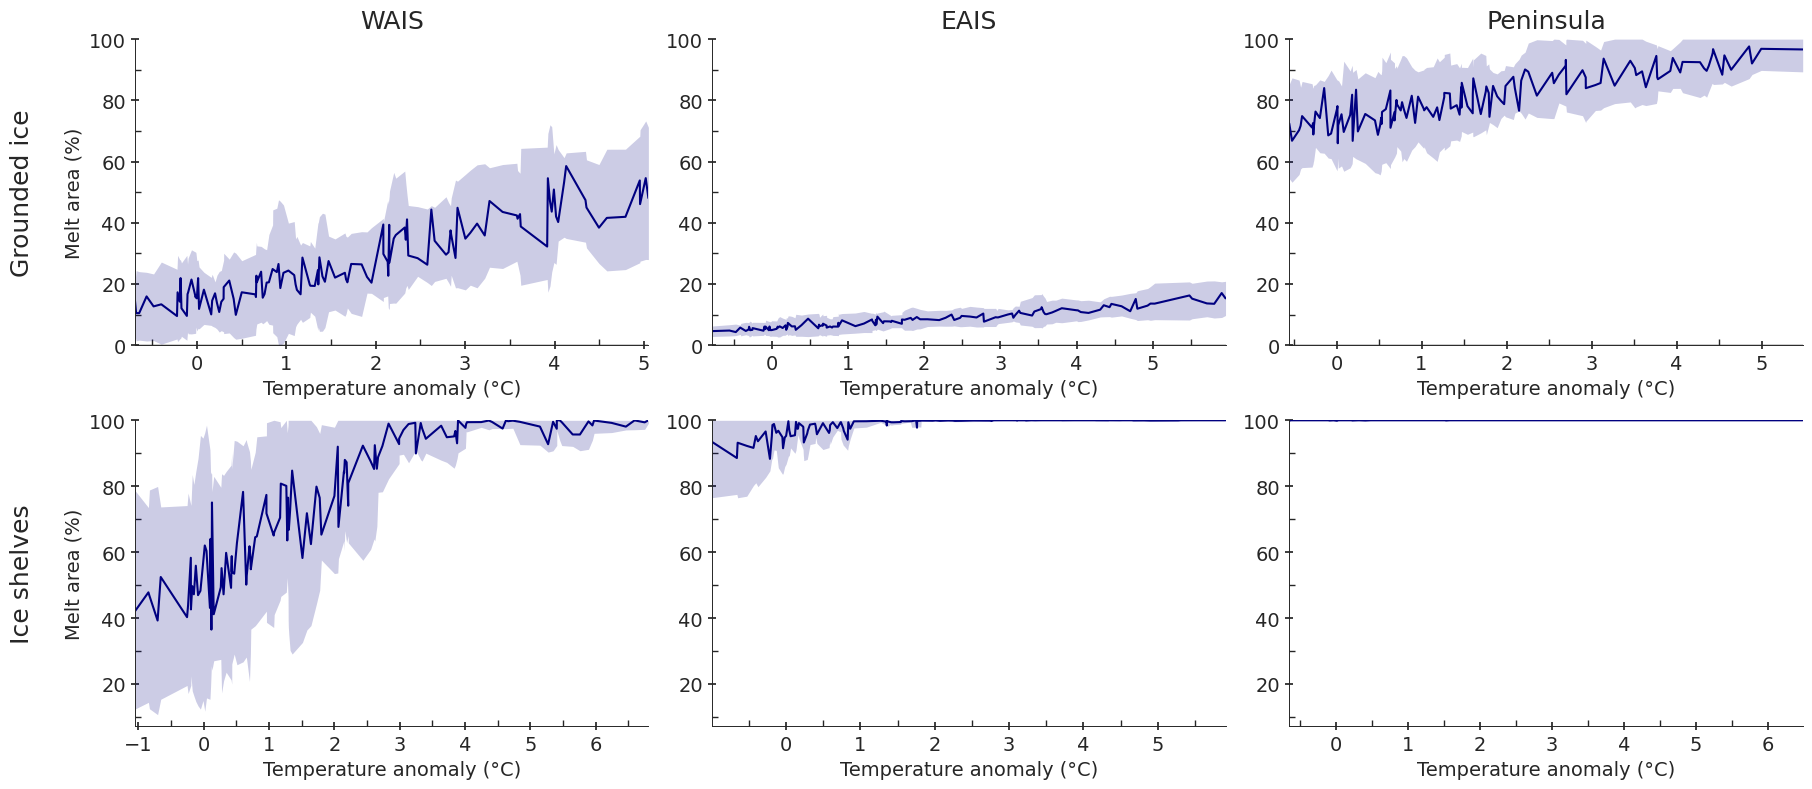

In [ ]:
MELT_AREA_THR = 1.0    
ROLL = 5               
ORDER = "T"          
SMOOTH_MEAN = False    
SHARE_X = False        
CAP, PAD = 100.0, 0.04
ROW_YLIMS = {}         
CI = 1.64
COLOR, ALPHA, LW = "navy", 0.20, 1.5

SECTORS = {
    "WAIS": [1, 2, 9, 14, 18, 19, 19.5, 20, 20.5, 24, 24.5],
    "EAIS": [3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 21, 21.5, 22, 23, 23.5],
    "Peninsula": [15, 16, 17, 25, 25.5, 26, 26.5],
}
SURFACES = {"Grounded ice": cst["GROUND"],
            "Ice shelves": (cst["ICE"] - cst["GROUND"]).clip(min=0)}

sns.set_style("white")
plt.rcParams.update({"font.family": "DejaVu Sans", "axes.titlesize": 18,
                     "axes.labelsize": 14, "xtick.labelsize": 14,
                     "ytick.labelsize": 14, "legend.fontsize": 16})

print(f"AREA check: mean cell {float(cst['AREA'].mean()):.4g}, "
      f"AIS total {float((cst['AREA'] * (cst['AIS'] > 0)).sum()):.4g} "
      f"(km2 if the total is around 1.4e7)")


def sector_mask(codes, frac):
    """Ice-fraction and projection weights for one Rignot sector and surface type."""
    ais_w = cst["AIS"].where(cst["AIS"] > 0)
    return (ais_w * frac.where(frac > 30) * cst["AREA"] / 100.0
            ).where(cst["RIGNOT"].isin(codes))


def sector_series(mask, threshold=MELT_AREA_THR):
    """Area-weighted warming and melt-area fraction (%) per model."""
    w = mask.values
    tot = float(np.nansum(w))
    if not np.isfinite(tot) or tot <= 0:
        raise ValueError("sector mask has zero total weight")

    warming, melt_area = [], []
    for m in MODELS:
        tt = (flat(DS[m]["TT"]) * w).sum(dim=["X", "Y"], skipna=True) / tot
        tt = tt - tt.sel(TIME=slice(REF0, REF1)).mean("TIME", skipna=True)
        warming.append(np.asarray(tt.values, dtype=float))

        area = ((flat(DS[m]["ME"]) > threshold).astype(float) * w
                ).sum(dim=["X", "Y"], skipna=True) * 100.0 / tot
        melt_area.append(np.asarray(area.values, dtype=float))

    n = min(min(map(len, warming)), min(map(len, melt_area)))
    return np.array([r[:n] for r in warming]), np.array([r[:n] for r in melt_area])


def smooth(v, window=ROLL):
    if window <= 1:
        return v
    return pd.Series(v).rolling(window, center=True, min_periods=1).mean().to_numpy()



curves = {}
for surface, frac in SURFACES.items():
    for sector, codes in SECTORS.items():
        warming, melt_area = sector_series(sector_mask(codes, frac))
        x = np.nanmean(warming, 0)
        y = np.nanmean(melt_area, 0)
        s = np.nanstd(melt_area, 0, ddof=1)

        ok = np.isfinite(x) & np.isfinite(y) & np.isfinite(s)
        x, y, s = x[ok], y[ok], s[ok]
        lo, hi = y - CI * s, y + CI * s

        if ORDER == "time":
            lo, hi = smooth(lo), smooth(hi)
            if SMOOTH_MEAN:
                y = smooth(y)
        rank = np.argsort(x)
        x, y, lo, hi = x[rank], y[rank], lo[rank], hi[rank]
        if ORDER == "T":
            lo, hi = smooth(lo), smooth(hi)
            if SMOOTH_MEAN:
                y = smooth(y)

        curves[(surface, sector)] = (x, y, np.clip(lo, 0, CAP), np.clip(hi, 0, CAP))

ylim, xlim = {}, {}
for surface in SURFACES:
    if surface in ROW_YLIMS:
        ylim[surface] = ROW_YLIMS[surface]
    else:
        lo = min(float(curves[(surface, s)][2].min()) for s in SECTORS)
        hi = max(float(max(curves[(surface, s)][3].max(), curves[(surface, s)][1].max()))
                 for s in SECTORS)
        margin = PAD * max(hi - lo, 1.0)
        ylim[surface] = (max(0.0, lo - margin), min(CAP, hi + margin))
    xlim[surface] = (min(float(curves[(surface, s)][0].min()) for s in SECTORS),
                     max(float(curves[(surface, s)][0].max()) for s in SECTORS))

fig, axs = plt.subplots(2, 3, figsize=(18, 8))

for i, surface in enumerate(SURFACES):
    for j, sector in enumerate(SECTORS):
        x, y, lo, hi = curves[(surface, sector)]
        ax = axs[i, j]
        ax.fill_between(x, np.minimum(lo, hi), np.maximum(lo, hi),
                        color=COLOR, alpha=ALPHA, lw=0, zorder=1)
        ax.plot(x, y, color=COLOR, lw=LW, zorder=2)
        ax.axhline(0, color="black", lw=1, zorder=0)

        for axis, side in (("x", dict(top=False, bottom=True)),
                           ("y", dict(left=True, right=False))):
            ax.tick_params(axis=axis, which="major", labelsize=14, direction="inout", **side)
            ax.tick_params(axis=axis, which="minor", direction="in", **side)
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))

        ax.set_xlim(*(xlim[surface] if SHARE_X else (np.nanmin(x), np.nanmax(x))))
        ax.set_ylim(*ylim[surface])
        ax.set_xlabel("Temperature anomaly (°C)", fontsize=14)
        if j == 0:
            ax.set_ylabel("Melt area (%)", fontsize=14)
        if i == 0:
            ax.set_title(sector, fontsize=18, pad=8)

        print(f"{surface:13s} {sector:10s}  ΔT {x.min():+.2f} to {x.max():+.2f} °C   "
              f"melt area {y[0]:6.2f} → {y[-1]:6.2f} %")

    axs[i, 0].text(-0.22, 0.5, surface, transform=axs[i, 0].transAxes, rotation=90,
                   va="center", ha="center", fontsize=18)

sns.despine(fig=fig)
plt.tight_layout()
fig.savefig(FIG_DIR / f"ed4_melt_area_vs_dT_roll{ROLL}_thr{MELT_AREA_THR:g}.png",
            dpi=200, bbox_inches="tight")
plt.show()

MAR-CNRM    AOA = 1 reached on 15% of the ice sheet, already exceeded on 39% of those
MAR-IPSL    AOA = 1 reached on 12% of the ice sheet, already exceeded on 42% of those
MAR-MPI     AOA = 1 reached on 9% of the ice sheet, already exceeded on 42% of those
MAR-UKESM   AOA = 1 reached on 11% of the ice sheet, already exceeded on 71% of those


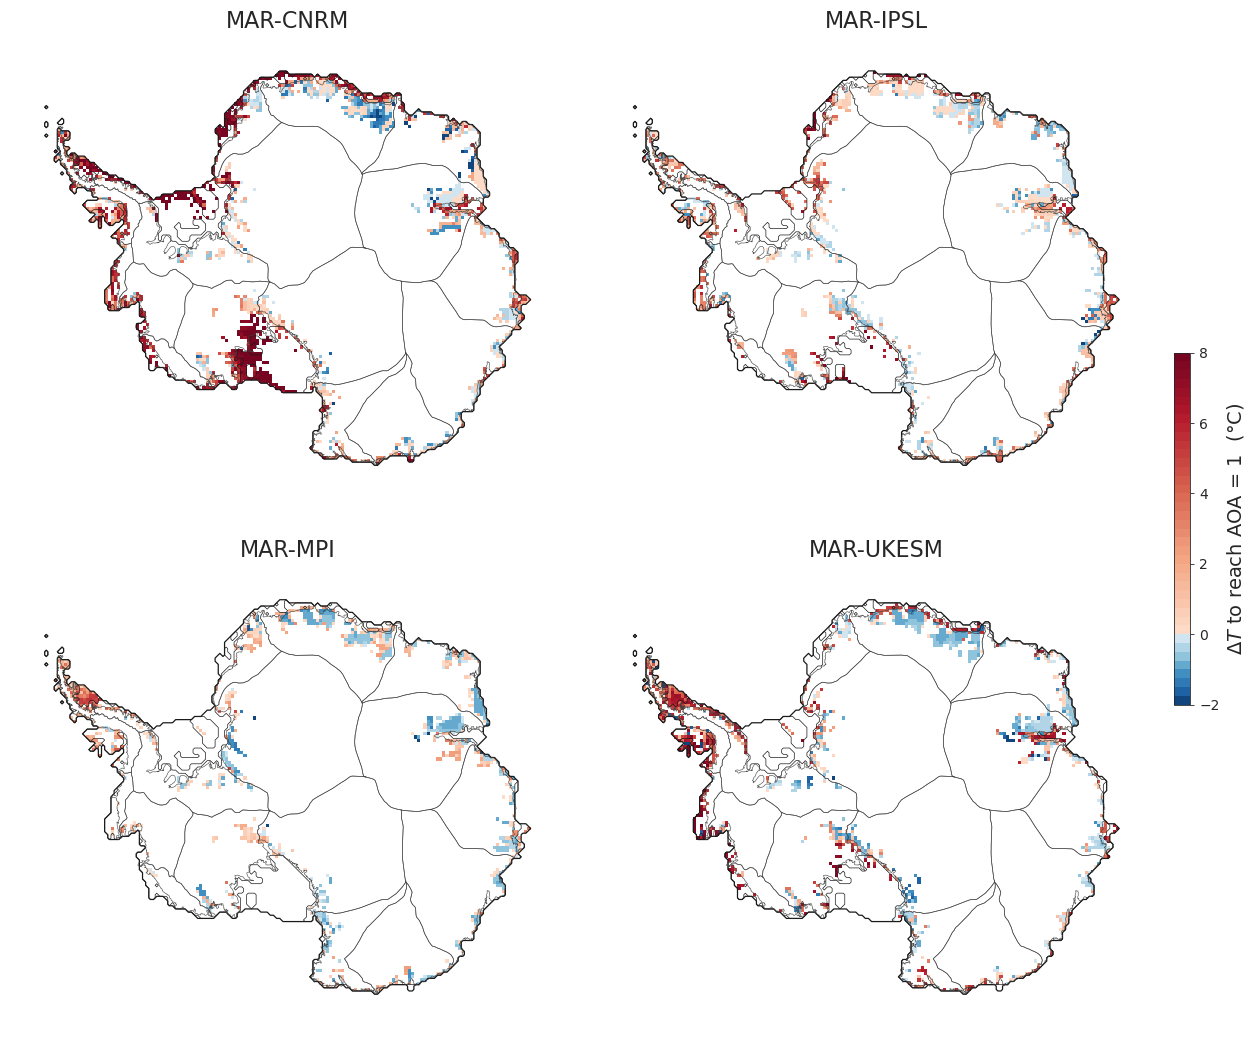

In [ ]:
AOA_THRESHOLD = 1.0
SMOOTH_AOA = 0
TICKS_AOA = np.arange(-2, 9, 2)


def aoa_ratio(ds):
    """Ablation over accumulation, (ER + SU + RU) / (SF + RF), per pixel per year."""
    ablation = flat(ds["ER"]) + flat(ds["SU"]) + flat(ds["RU"])
    precip = flat(ds["SF"]) + flat(ds["RF"])
    return xr.where(precip > 0, ablation / precip, np.nan)


def tt_at_aoa(ds, threshold=AOA_THRESHOLD, smooth=SMOOTH_AOA):
    """Per-pixel warming at which AOA first reach the threshold."""
    aoa = aoa_ratio(ds)
    tt = tt_anomaly(ds)
    if smooth:
        aoa = aoa.rolling(TIME=smooth, center=True, min_periods=1).mean()
        tt = tt.rolling(TIME=smooth, center=True, min_periods=1).mean()
    aoa, tt = aoa.load(), tt.load()
    exceed = aoa >= threshold
    onset = tt.isel(TIME=exceed.argmax("TIME")).where(exceed.any("TIME"))
    return np.asarray(onset.squeeze(drop=True).transpose("Y", "X"), dtype=float)


fig, axes = plt.subplots(2, 2, figsize=(13, 11))
outlines = gdf[gdf["Subregion"].str.strip() != "Islands"].geometry.simplify(2000)

for ax, m in zip(axes.ravel(), MODELS):
    z = tt_at_aoa(DS[m])
    masked = ma.array(z, mask=lsm | ~ais_mask | ~np.isfinite(z))
    mesh = ax.pcolormesh(x2m, y2m, masked, cmap=CMAP_DT, norm=NORM_DT,
                         shading="auto", rasterized=True, zorder=3)

    ax.contour(x2m, y2m, ICE.astype(float), [0.5], colors="0.1", linewidths=0.9, zorder=7)
    ax.contour(x2m, y2m, GROUND.astype(float), [0.5], colors="0.1", linewidths=0.5, zorder=7)
    outlines.boundary.plot(ax=ax, color="0.25", lw=0.45, alpha=0.9, zorder=8)

    ax.set_title(LONG_NAME[m], fontsize=16)
    ax.set_aspect("equal")
    ax.axis("off")
    print(f"{LONG_NAME[m]:<11s} AOA = {AOA_THRESHOLD:g} reached on "
          f"{np.isfinite(z)[ais_mask].mean() * 100:.0f}% of the ice sheet, "
          f"already exceeded on {(z[np.isfinite(z)] < 0).mean() * 100:.0f}% of those")

cax = fig.add_axes([0.915, 0.34, 0.013, 0.32])
cbar = fig.colorbar(mesh, cax=cax, ticks=TICKS_AOA)
cbar.set_label(rf"$\Delta T$ to reach AOA = {AOA_THRESHOLD:g}  (°C)", fontsize=14)
cbar.ax.minorticks_off()
cbar.ax.tick_params(labelsize=10, length=3, width=0.6)
cbar.outline.set_linewidth(0.6)

fig.patch.set_facecolor("white")
plt.subplots_adjust(wspace=0.06, hspace=0.12, left=0.02, right=0.90, top=0.95, bottom=0.04)
fig.savefig(FIG_DIR / f"ed5_aoa_map_thr{AOA_THRESHOLD:g}.png", dpi=200, bbox_inches="tight")
plt.show()

MAR-CNRM    melt line   1113 →   1663 m  (+550 m), ΔT +4.71 °C, summit-limited in 0 of 121 years
MAR-IPSL    melt line   1123 →   1606 m  (+483 m), ΔT +4.35 °C, summit-limited in 0 of 121 years
MAR-MPI     melt line   1159 →   1442 m  (+282 m), ΔT +2.94 °C, summit-limited in 0 of 121 years
MAR-UKESM   melt line   1049 →   1668 m  (+619 m), ΔT +5.41 °C, summit-limited in 0 of 121 years

four-model mean rise +484 m (spread +282 to +619 m), bands 0-4100 m


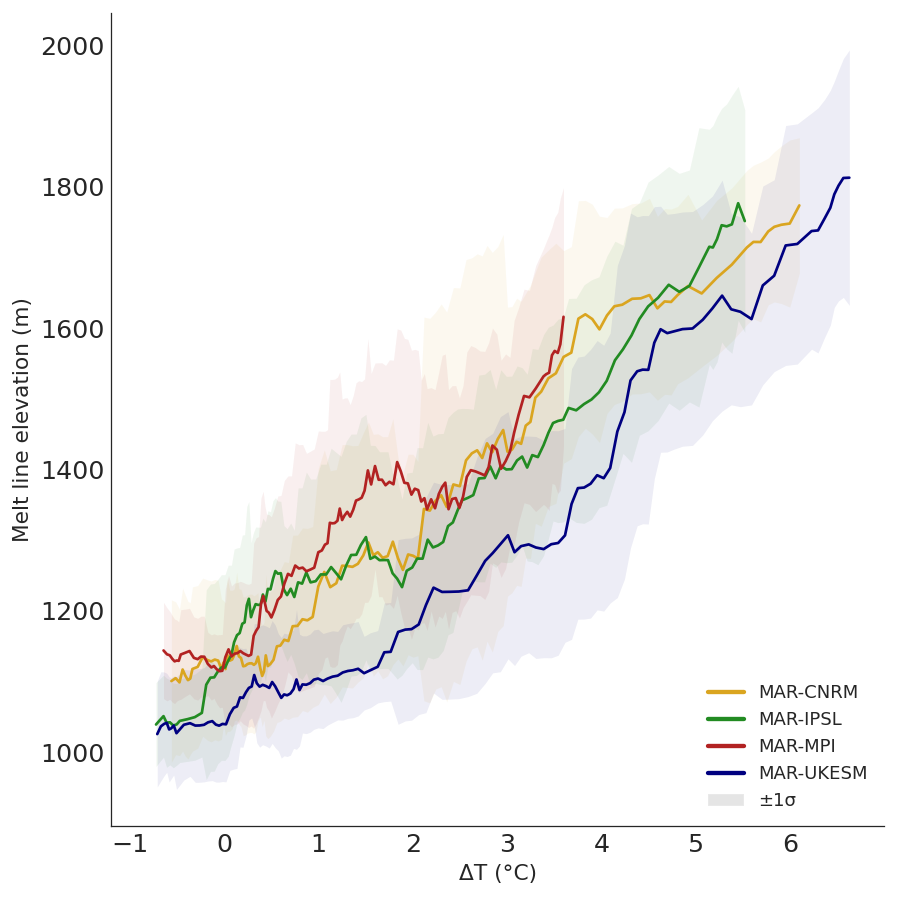

In [ ]:
MELT_LINE_THR = 1.0     
Z_STEP = 100          
NSMOOTH = 15            
BAND_KIND = "std"       # "std" for ±1σ, "pct" for the 16-84th percentile
DT_BAND = None          
Z_MAX = int(np.ceil(np.nanmax(SH[grd_frac > 0]) / Z_STEP) * Z_STEP)
edges = np.arange(0, Z_MAX + Z_STEP, Z_STEP)
mids = edges[:-1] + Z_STEP / 2

if DT_BAND is None:
    w_dt = grd_frac * AREA_2D
else:
    in_band = np.isfinite(SH) & (SH >= DT_BAND[0]) & (SH < DT_BAND[1])
    w_dt = grd_frac * in_band.astype(float) * AREA_2D


def wmean_ts(cube, w):
    """Area-weighted spatial mean per year vectorised aw_mean."""
    finite = np.isfinite(cube)
    num = np.nansum(np.where(finite, cube, 0.0) * w[None], axis=(1, 2))
    den = np.nansum(finite * w[None], axis=(1, 2))
    out = np.full(num.shape, np.nan)
    out[den > 0] = num[den > 0] / den[den > 0]
    return out


def melt_line(profile, z, threshold):

    ok = np.isfinite(profile)
    if ok.sum() < 2:
        return np.nan, False
    zz, mm = z[ok], profile[ok]
    above = np.where(mm >= threshold)[0]
    if above.size == 0:
        return np.nan, False
    i = above[-1]                      
    if i == len(mm) - 1:
        return float(zz[i]), True       
    m0, m1, z0, z1 = mm[i], mm[i + 1], zz[i], zz[i + 1]
    if m0 == m1:
        return float(z0), False
    return float(z0 + (m0 - threshold) / (m0 - m1) * (z1 - z0)), False


def trend_band(x, y, n=NSMOOTH, kind=BAND_KIND):
    """Sort by warming, then roll: mean gives the response, spread gives the band."""
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 3:
        return (np.array([]),) * 4
    order = np.argsort(x[ok])
    sx, sy = pd.Series(x[ok][order]), pd.Series(y[ok][order])
    roll = dict(window=n, center=True, min_periods=max(3, n // 2))
    xt = sx.rolling(**roll).mean().to_numpy()
    yt = sy.rolling(**roll).mean().to_numpy()
    if kind == "pct":
        return xt, yt, sy.rolling(**roll).quantile(0.16).to_numpy(), \
               sy.rolling(**roll).quantile(0.84).to_numpy()
    sd = sy.rolling(**roll).std().to_numpy()
    return xt, yt, yt - sd, yt + sd


trajectories = {}
for m in MODELS:
    me = flat(DS[m]["ME"])
    years = me["TIME"].dt.year.values
    cube = me.values

    profile = np.full((len(mids), len(years)), np.nan)
    for k, z_lo in enumerate(edges[:-1]):
        cells = np.isfinite(SH) & (SH >= z_lo) & (SH < z_lo + Z_STEP) & (grd_frac > 0)
        if cells.any():
            profile[k] = wmean_ts(cube, grd_frac * cells.astype(float) * AREA_2D)

    line, ceiling = zip(*(melt_line(profile[:, t], mids, MELT_LINE_THR)
                          for t in range(len(years))))
    line = np.array(line, dtype=float)

    dt = wmean_ts(np.asarray(tt_anomaly(DS[m]).values, dtype=float), w_dt)
    trajectories[m] = {"dT": dt, "line": line, "years": years}

    ref = np.nanmean(line[(years >= 1981) & (years <= 2010)])
    fut = np.nanmean(line[(years >= 2071) & (years <= 2100)])
    print(f"{LONG_NAME[m]:<11s} melt line {ref:6.0f} → {fut:6.0f} m  ({fut - ref:+.0f} m), "
          f"ΔT {np.nanmean(dt[(years >= 2071)]):+.2f} °C, "
          f"summit-limited in {sum(ceiling)} of {len(years)} years")

rise = [np.nanmean(t["line"][(t["years"] >= 2071)])
        - np.nanmean(t["line"][(t["years"] >= 1981) & (t["years"] <= 2010)])
        for t in trajectories.values()]
print(f"\nfour-model mean rise {np.mean(rise):+.0f} m (spread {np.min(rise):+.0f} "
      f"to {np.max(rise):+.0f} m), bands 0-{Z_MAX} m")

fig, ax = plt.subplots(figsize=(7, 7), dpi=130)

for m, traj in trajectories.items():
    xt, yt, lo, hi = trend_band(traj["dT"], traj["line"])
    if not xt.size:
        continue
    ax.fill_between(xt, lo, hi, color=MODELS[m], alpha=0.07, lw=0, zorder=2)
    ax.plot(xt, yt, color=MODELS[m], lw=1.5, zorder=4, solid_capstyle="round")

band_label = "16-84th pct" if BAND_KIND == "pct" else "±1σ"
ax.legend(handles=[Line2D([], [], color=MODELS[m], lw=2.4, label=LONG_NAME[m])
                   for m in trajectories] +
                  [Patch(facecolor="gray", alpha=0.2, label=band_label)],
          frameon=False, fontsize=10, loc="lower right")

ax.set_xlabel("ΔT (°C)", fontsize=12)
ax.set_ylabel("Melt line elevation (m)", fontsize=12)
ax.set_xlim(left=min(0.0, float(np.nanmin([np.nanmin(t["dT"]) for t in trajectories.values()]))))
ax.tick_params(direction="in", which="both")
sns.despine(ax=ax)

fig.tight_layout()
fig.savefig(FIG_DIR / f"ed6_meltline_vs_dT_thr{MELT_LINE_THR:g}.png",
            dpi=200, bbox_inches="tight")
plt.show()

EAIS       grounded area  9.73 x10^6 km2
WAIS       grounded area  2.20 x10^6 km2
Peninsula  grounded area  0.27 x10^6 km2


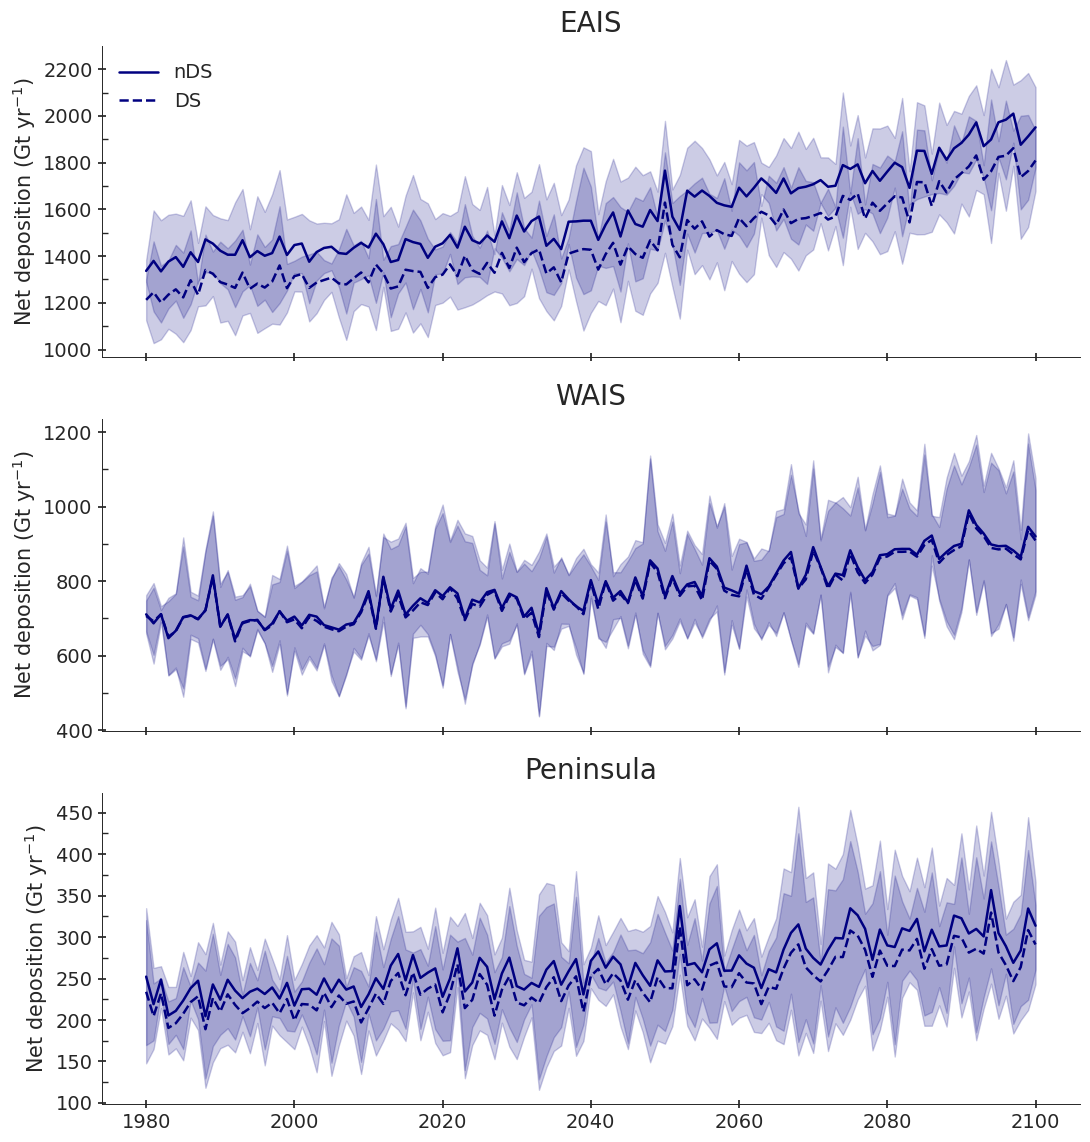


Gt yr-1;  gap = dSF - ER_DS


SF_DS   SF_nDS      dSF    ER_DS  ER_pct_of_SF  \
period    region                                                        
1981-2010 EAIS       3497.32  1416.68  2080.64  2213.34         63.29   
          WAIS       1429.61   697.78   731.83   734.62         51.39   
          Peninsula   368.80   232.25   136.55   153.81         41.70   
2071-2100 EAIS       4081.51  1831.89  2249.62  2388.39         58.52   
          WAIS       1645.73   880.40   765.33   773.61         47.01   
          Peninsula   438.06   303.48   134.58   158.01         36.07   

                     netdep_DS  netdep_nDS     gap  
period    region                                    
1981-2010 EAIS         1283.98     1416.68 -132.70  
          WAIS          694.99      697.78   -2.79  
          Peninsula     215.00      232.25  -17.26  
2071-2100 EAIS         1693.12     1831.89 -138.77  
          WAIS          872.13      880.40   -8.27  
          Peninsula     280.05      303.48  -23.43

In [ ]:
PER_MODEL = False
SPREAD = 1.64
SECTORS = {
    "EAIS": [3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 21, 21.5, 22, 23, 23.5],
    "WAIS": [1, 2, 9, 14, 18, 19, 19.5, 20, 20.5, 24, 24.5],
    "Peninsula": [15, 16, 17, 25, 25.5, 26, 26.5],
}

grd_w = (cst["AIS"].where(cst["AIS"] > 0)
         * cst["GROUND"].where(cst["GROUND"] > 30) * cst["AREA"] / 100)
region_w = {r: grd_w.where(cst["RIGNOT"].isin(codes)) for r, codes in SECTORS.items()}


def to_gt(da, w):
    """kg m-2 yr-1 on the grid to Gt yr-1 over the weighted region."""
    return (da * w.values).sum(dim=["X", "Y"]) * RESOLUTION ** 2 / 1e12


for r, w in region_w.items():
    print(f"{r:<10s} grounded area {float(w.sum()) * RESOLUTION ** 2 / 1e12:5.2f} x10^6 km2")

sf, er, netdep = {}, {}, {}
for run, runs in (("nDS", NDS), ("DS", DS)):
    for r, w in region_w.items():
        sf[(run, r)] = pd.DataFrame({m: to_gt(flat(runs[m]["SF"]), w).to_series()
                                     for m in MODELS})
        if run == "DS":
            er[(run, r)] = pd.DataFrame({m: to_gt(flat(runs[m]["ER"]), w).to_series()
                                         for m in MODELS})
            netdep[(run, r)] = sf[(run, r)] - er[(run, r)]
        else:
            netdep[(run, r)] = sf[(run, r)]

fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=True)

for ax, r in zip(axes, SECTORS):
    for run, ls in (("nDS", "solid"), ("DS", "dashed")):
        df = netdep[(run, r)]
        if PER_MODEL:
            for m in MODELS:
                ax.plot(YEARS, df[m], color=MODELS[m], lw=1.5, ls=ls,
                        label=m if (r == "EAIS" and run == "nDS") else None)
        else:
            mean, std = df.mean(axis=1), df.std(axis=1)
            ax.plot(YEARS, mean, color="navy", lw=1.8, ls=ls,
                    label=run if r == "EAIS" else None)
            ax.fill_between(YEARS, mean - SPREAD * std, mean + SPREAD * std,
                            color="navy", alpha=0.2)

    ax.set_title(r, fontsize=20, pad=10)
    ax.set_ylabel("Net deposition (Gt yr$^{-1}$)", fontsize=15)
    ax.tick_params(axis="both", labelsize=14)
    ax.yaxis.set_minor_locator(AutoMinorLocator(n=2))
    ax.tick_params(axis="y", which="major", direction="inout", left=True, right=False)
    ax.tick_params(axis="y", which="minor", direction="in", left=True, right=False)
    ax.tick_params(axis="x", which="major", direction="inout", top=False, bottom=True)
    lo, hi = ax.get_ylim()
    if lo < 0 < hi:
        ax.axhline(color="black", alpha=0.7, lw=1)

axes[0].legend(frameon=False, prop={"size": 14}, loc="upper left")
sns.despine(fig=fig)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / "ed7_netdep_by_region.png", dpi=200, bbox_inches="tight")
plt.show()

# gap = netdep_DS - netdep_nDS = (SF_DS - SF_nDS) - ER_DS
rows = []
for label, window in (("1981-2010", slice(REF0, REF1)), ("2071-2100", slice(FUT0, FUT1))):
    for r in SECTORS:
        sf_ds = sf[("DS", r)][window].mean(axis=0).mean()
        sf_nds = sf[("nDS", r)][window].mean(axis=0).mean()
        er_ds = er[("DS", r)][window].mean(axis=0).mean()
        rows.append({"period": label, "region": r,
                     "SF_DS": sf_ds, "SF_nDS": sf_nds, "dSF": sf_ds - sf_nds,
                     "ER_DS": er_ds, "ER_pct_of_SF": 100 * er_ds / sf_ds,
                     "netdep_DS": netdep[("DS", r)][window].mean(axis=0).mean(),
                     "netdep_nDS": netdep[("nDS", r)][window].mean(axis=0).mean(),
                     "gap": (sf_ds - sf_nds) - er_ds})

print("\nGt yr-1;  gap = dSF - ER_DS")
display(pd.DataFrame(rows).set_index(["period", "region"]).round(2))

      0-50 m     4 px   T_cross = — °C  (no_cross)
    50-100 m    68 px   T_cross =  -0.79 °C  (data)
   100-150 m   148 px   T_cross = — °C  (no_cross)
   150-200 m   132 px   T_cross = — °C  (no_cross)
   200-250 m   110 px   T_cross =  -0.13 °C  (data)
   250-300 m   104 px   T_cross =  +1.50 °C  (data)
   300-350 m    88 px   T_cross =  +0.61 °C  (data)
   350-400 m    95 px   T_cross =  +1.79 °C  (data)
   400-450 m    83 px   T_cross =  +2.28 °C  (data)
   450-500 m    76 px   T_cross =  +1.93 °C  (data)
   500-550 m    88 px   T_cross =  +2.74 °C  (data)
   550-600 m    70 px   T_cross =  +3.46 °C  (data)
   600-650 m    90 px   T_cross =  +4.10 °C  (data)
   650-700 m    74 px   T_cross =  +4.95 °C  (data)
   700-750 m    72 px   T_cross =  +5.85 °C  (extrapolated)
   750-800 m    84 px   T_cross =  +5.35 °C  (extrapolated)
   800-850 m    91 px   T_cross =  +7.50 °C  (extrapolated)
   850-900 m   112 px   T_cross =  +8.16 °C  (extrapolated)
   900-950 m   111 px   T_cross =  

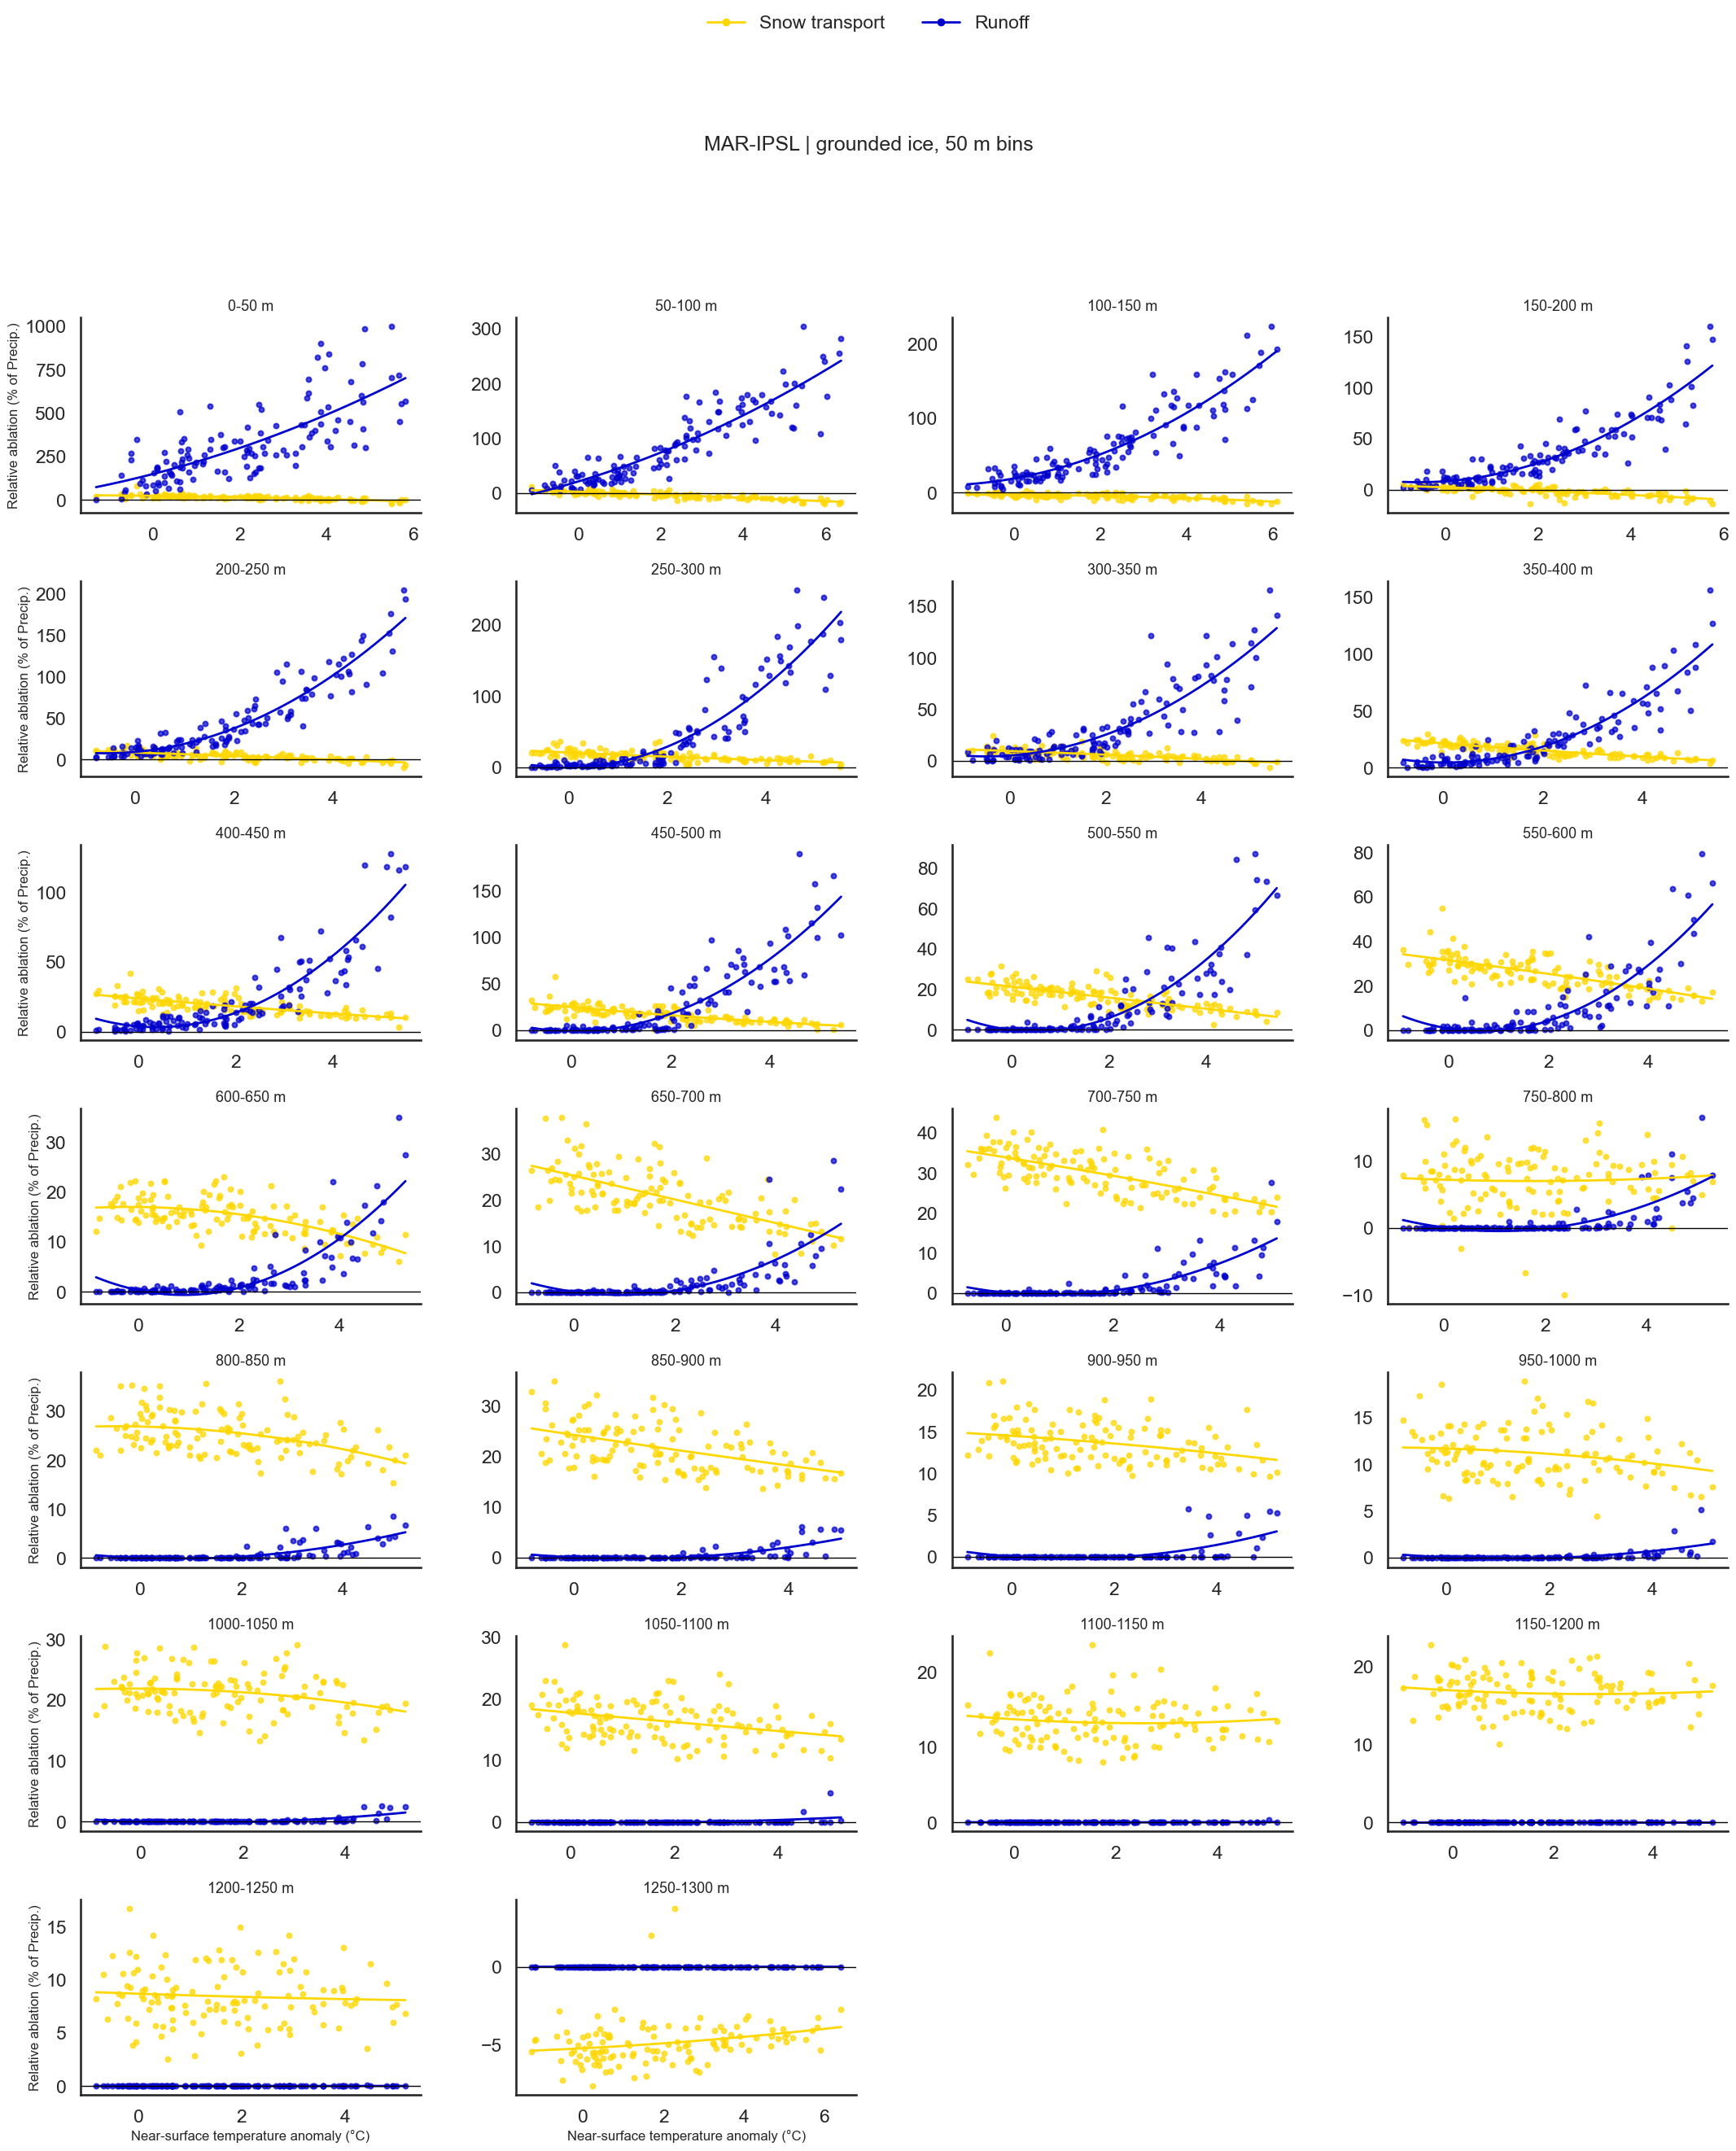

In [ ]:


MODEL = "IPSL"          #change the name of the model here 
BIN_STEP = 50           # m
BIN_MAX = 1300          # m, top of the binned range over grounded ice
NCOLS = 4
DEG = 2

edges = np.arange(0, BIN_MAX + BIN_STEP, BIN_STEP)
COLORS = {"Snow transport": "gold", "Runoff": "mediumblue"}

sns.set_style("white")
sns.set_context("talk")   

dsD, dsN = DS[MODEL], NDS[MODEL]
tta = tt_anomaly(dsD)
precip = flat(dsN["SF"]) + flat(dsN["RF"])
netdep = flat(dsD["SF"]) + flat(dsD["RF"]) - flat(dsD["ER"])
rel = {"Snow transport": 100.0 * (precip - netdep) / precip,
       "Runoff": 100.0 * flat(dsD["RU"]) / precip}

bins = []
for lo, hi in zip(edges[:-1], edges[1:]):
    top = hi if hi < BIN_MAX else np.inf      
    cells = (grd_frac > 0) & np.isfinite(SH) & (SH >= lo) & (SH < top)
    if cells.any():
        bins.append((f"{int(lo)}-{int(hi)} m", grd_frac * cells.astype(float) * AREA_2D,
                     int(cells.sum())))

nrows = int(np.ceil(len(bins) / NCOLS))
fig, axs = plt.subplots(nrows, NCOLS, figsize=(22, 4 * nrows))
axs = np.array(axs).reshape(-1)

for i, (label, w, npix) in enumerate(bins):
    ax = axs[i]
    x = aw_mean(tta, w)
    y = {k: aw_mean(v, w) for k, v in rel.items()}

    for name, color in COLORS.items():
        ax.scatter(x, y[name], s=18, color=color, alpha=0.7)
        ok = np.isfinite(x) & np.isfinite(y[name])
        if ok.sum() >= 8:
            p = np.polyfit(x[ok], y[name][ok], DEG)
            xs = np.linspace(x[ok].min(), x[ok].max(), 200)
            ax.plot(xs, np.polyval(p, xs), color=color, lw=2)

    tcross, flag = poly_cross(x, y["Snow transport"], y["Runoff"], deg=DEG)
    ax.axhline(0, color="black", lw=1)
    ax.set_title(label, fontsize=13)
    ax.grid(False)
    if i // NCOLS == nrows - 1:
        ax.set_xlabel("Near-surface temperature anomaly (°C)", fontsize=12)
    if i % NCOLS == 0:
        ax.set_ylabel("Relative ablation (% of Precip.)", fontsize=12)

    print(f"{label:>12s}  {npix:4d} px   T_cross = "
          f"{'—' if not np.isfinite(tcross) else format(tcross, '+6.2f')} °C  ({flag})")

for ax in axs[len(bins):]:
    ax.axis("off")

fig.legend(handles=[plt.Line2D([0], [0], color=c, lw=2, marker="o", ms=6, label=k)
                    for k, c in COLORS.items()],
           loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle(f"{LONG_NAME[MODEL]} | grounded ice, {BIN_STEP} m bins", fontsize=18, y=0.96)
plt.subplots_adjust(left=0.06, right=0.98, top=0.88, bottom=0.10, wspace=0.28, hspace=0.35)
sns.despine()
fig.savefig(FIG_DIR / f"ed8_elevation_bins_{MODEL}_{BIN_STEP}m.png",
            dpi=200, bbox_inches="tight")
plt.show()
sns.set_context("notebook")